# An    lise de S    rie Temporal de Produ        o

Este notebook realiza uma an    lise detalhada da s    rie temporal de produ        o, integrando vari    veis ex    genas e eventos, com foco em engenharia de features e identifica        o das vari    veis mais relevantes para modelagem com XGBoost, SARIMAX e HoltWinters.

**Etapas:**
1. Importar bibliotecas necess    rias
2. Carregar e visualizar os dados
3. Pr    -processamento dos dados
4. Engenharia de features
5. An    lise explorat    ria das s    ries temporais
6. An    lise de correla        o entre produ        o, vari    veis ex    genas e eventos
7. Sele        o de features relevantes
8. Prepara        o dos dados para modelos de s    ries temporais
9. Configura        o inicial dos modelos XGBoost, SARIMAX e HoltWinters



## 1. Importar Bibliotecas Necess    rias

Vamos importar as principais bibliotecas para an    lise de dados, visualiza        o, engenharia de features e modelagem de s    ries temporais.


In [1]:
# Bibliotecas para an    lise de dados e s    ries temporais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Bibliotecas para modelagem
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Configura        es de visualiza        o
ds_pal = sns.color_palette('Set2')
sns.set(style='whitegrid', palette=ds_pal)
plt.rcParams['figure.figsize'] = (14, 6)



C:\Users\rafael.franca\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 2. Carregar e Visualizar os Dados

Vamos carregar os arquivos CSV de produ        o e vari    veis ex    genas/eventos, visualizar as primeiras linhas e verificar os tipos de dados.


In [2]:
# =====================
# Funcoes de features avancadas e ajuste de eventos
# =====================
import numpy as _np

def criar_proximidade_evento(df, coluna_evt):
    idx_evt = df.index[df.get(coluna_evt, 0) == 1].to_numpy()
    dias = _np.full(len(df), 999, dtype=int)
    if idx_evt.size == 0:
        return pd.Series(dias, index=df.index)
    for i in range(len(df)):
        d = idx_evt - i
        d_pos = d[d >= 0]
        d_neg = d[d < 0]
        dias_ate = int(d_pos.min()) if d_pos.size else 999
        dias_desde = int(d_neg.max()) if d_neg.size else -999
        dias[i] = dias_ate if abs(dias_ate) <= abs(dias_desde) else dias_desde
    return pd.Series(dias, index=df.index)

def criar_features_avancadas(df):
    if 'dia_semana' not in df.columns:
        df['dia_semana'] = df['data'].dt.dayofweek
    if 'dia' not in df.columns:
        df['dia'] = df['data'].dt.day
    # Tendencia
    df['dias_desde_inicio'] = (df['data'] - df['data'].min()).dt.days
    df['tendencia_linear'] = df['dias_desde_inicio'] / 365.0
    # Ciclicas
    df['dia_ano'] = df['data'].dt.dayofyear
    df['sin_dia_ano'] = _np.sin(2*_np.pi*df['dia_ano']/365.0)
    df['cos_dia_ano'] = _np.cos(2*_np.pi*df['dia_ano']/365.0)
    df['sin_dia_semana'] = _np.sin(2*_np.pi*df['dia_semana']/7.0)
    df['cos_dia_semana'] = _np.cos(2*_np.pi*df['dia_semana']/7.0)
    df['sin_dia_mes'] = _np.sin(2*_np.pi*df['dia']/30.0)
    df['cos_dia_mes'] = _np.cos(2*_np.pi*df['dia']/30.0)
    # Interacoes
    df['inicio_mes'] = (df['dia'] <= 5).astype(int)
    df['fim_mes'] = (df['dia'] >= 25).astype(int)
    df['meio_semana'] = df['dia_semana'].isin([2,3,4]).astype(int)
    # Eventos
    evt_cols = [c for c in df.columns if c.startswith('evt_')]
    for c in evt_cols:
        prox = criar_proximidade_evento(df, c)
        df[f'dias_ate_{c}'] = prox
        df[f'janela_{c}'] = (prox.abs() <= 3).astype(int)
    # Dinamica
    if 'producao' in df.columns:
        if 'producao_ma_7' in df.columns:
            df['std_rolling_7'] = df['producao'].rolling(7, min_periods=1).std()
            df['cv_rolling_7'] = df['std_rolling_7'] / df['producao_ma_7'].replace(0, _np.nan)
        df['mudanca_percentual_7d'] = df['producao'].pct_change(7)
        if 'producao_ma_7' in df.columns:
            df['aceleracao_producao'] = df['producao_ma_7'].diff()
        else:
            df['aceleracao_producao'] = _np.nan
    return df

class TratadorEventosEspeciais:
    def __init__(self):
        self.impactos_eventos = {}
    def calcular_impacto_eventos(self, df):
        base = df.copy()
        if 'dia_semana' not in base.columns:
            base['dia_semana'] = base['data'].dt.dayofweek
        base['baseline'] = base.groupby('dia_semana')['producao'].transform(lambda x: x.rolling(4, min_periods=1).mean().shift(1))
        for c in [c for c in base.columns if c.startswith('evt_')]:
            m = base[c] == 1
            if m.any() and base.loc[m, 'baseline'].notna().any():
                imp = (base.loc[m, 'producao'] / base.loc[m, 'baseline']).replace([_np.inf, -_np.inf], _np.nan).dropna().mean()
                if _np.isfinite(imp):
                    self.impactos_eventos[c] = float(imp)
        return self.impactos_eventos
    def ajustar_previsao_eventos(self, df_futuro, previsoes):
        out = _np.array(previsoes, dtype=float).copy()
        if len(out) != len(df_futuro):
            return out
        for i, row in df_futuro.reset_index(drop=True).iterrows():
            mult = 1.0
            for evt, imp in self.impactos_eventos.items():
                if evt in row and row[evt] == 1:
                    mult *= (0.3 + 0.7*imp)
            out[i] *= mult
        return out

# Flag global para ajuste de eventos no ensemble final
AJUSTE_EVENTOS = True

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def validacao_temporal_robusta(df, modelo, features_cols):
    resultados = []
    for dias in [30, 60, 90]:
        cutoff = df['data'].max() - pd.Timedelta(days=dias)
        tr = df[df['data'] < cutoff]
        te = df[df['data'] >= cutoff]
        if len(tr) == 0 or len(te) == 0:
            continue
        Xtr, ytr = tr[features_cols], tr['producao']
        Xte, yte = te[features_cols], te['producao']
        try:
            modelo.fit(Xtr, ytr)
            pred = modelo.predict(Xte)
        except Exception:
            continue
        resultados.append({
            'horizonte_dias': dias,
            'MAPE': mean_absolute_percentage_error(yte, pred),
            'RMSE': float(_np.sqrt(mean_squared_error(yte, pred))),
            'MAE': mean_absolute_error(yte, pred),
            'R2': r2_score(yte, pred),
            'max_error_abs': float(_np.max(_np.abs(yte - pred)))
        })
    return pd.DataFrame(resultados)



In [3]:
# Caminhos dos arquivos
caminho_producao = r'C:/Users/rafael.franca/OneDrive - JADLOG LOGISTICA LTDA/Meu Computador/GitHubCopilot/Historico.csv'
caminho_exogenas = r'C:/Users/rafael.franca/OneDrive - JADLOG LOGISTICA LTDA/Meu Computador/GitHubCopilot/variaveis_exogenas_vertical.csv'

# Fun        o robusta para leitura de CSV com delimitador e encoding inferidos
def ler_csv_robusto(caminho, prefer_sep=';'):
    import pandas as pd
    # Tenta com separador ';' (comum em PT-BR) e UTF-8
    try:
        return pd.read_csv(caminho, sep=prefer_sep, encoding='utf-8')
    except UnicodeDecodeError:
        # Tenta latin-1/cp1252
        try:
            return pd.read_csv(caminho, sep=prefer_sep, encoding='latin-1')
        except Exception:
            return pd.read_csv(caminho, sep=prefer_sep, encoding='cp1252')
    except Exception:
        # Fallback: tenta autodetectar separador
        try:
            return pd.read_csv(caminho, sep=None, engine='python')
        except UnicodeDecodeError:
            return pd.read_csv(caminho, sep=None, engine='python', encoding='latin-1')

# Carregar dados
producao = ler_csv_robusto(caminho_producao)
exogenas = ler_csv_robusto(caminho_exogenas)

# Visualizar primeiras linhas e colunas
print('Colunas em producao:', producao.columns.tolist())
print('Colunas em exogenas:', exogenas.columns.tolist())
display(producao.head())
display(exogenas.head())

# Informa        es b    sicas
print('\nInfo producao:')
producao.info()
print('\nInfo exogenas:')
exogenas.info()


Colunas em producao: ['Data', 'Filial', 'producao']
Colunas em exogenas: ['data', 'ano', 'mes', 'dia', 'dia_semana', 'semana_do_mes', 'tipo_de_dia', 'e_fim_de_semana', 'nome_feriado', 'nome_feriado_regional', 'evento']


,Data,Filial,producao
0,01/01/2024,TECA,8.000
1,02/01/2024,TECA,61.103
2,03/01/2024,TECA,93.236
3,04/01/2024,TECA,129.560
4,05/01/2024,TECA,123.660


,data,ano,mes,dia,dia_semana,semana_do_mes,tipo_de_dia,e_fim_de_semana,nome_feriado,nome_feriado_regional,evento
0,01/01/2024,2024,1,1,segunda-feira,1,feriado,FALSO,Confraternização Universal,NaN,feriado_nacional
1,02/01/2024,2024,1,2,terça-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas
2,03/01/2024,2024,1,3,quarta-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas
3,04/01/2024,2024,1,4,quinta-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas
4,05/01/2024,2024,1,5,sexta-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas



Info producao:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Data      653 non-null    object 
 1   Filial    653 non-null    object 
 2   producao  653 non-null    float64
dtypes: float64(1), object(2)
memory usage: 15.8+ KB

Info exogenas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data                   450 non-null    object 
 1   ano                    450 non-null    int64  
 2   mes                    450 non-null    int64  
 3   dia                    450 non-null    int64  
 4   dia_semana             450 non-null    object 
 5   semana_do_mes          450 non-null    int64  
 6   tipo_de_dia            450 non-null    object 
 7   e_fim_de_semana        450 non-null   

## 3. Pr    -processamento dos Dados

Nesta etapa, vamos tratar valores ausentes, converter colunas de datas, alinhar as bases e fazer o merge dos eventos/vari    veis ex    genas com a produ        o.


In [4]:
# Diagn    stico das colunas antes do pr    -processamento
print('Colunas em producao:', producao.columns.tolist())
print('Colunas em exogenas:', exogenas.columns.tolist())
print('\nPrimeiras linhas de producao:')
display(producao.head())
print('\nPrimeiras linhas de exogenas:')
display(exogenas.head())


Colunas em producao: ['Data', 'Filial', 'producao']
Colunas em exogenas: ['data', 'ano', 'mes', 'dia', 'dia_semana', 'semana_do_mes', 'tipo_de_dia', 'e_fim_de_semana', 'nome_feriado', 'nome_feriado_regional', 'evento']

Primeiras linhas de producao:


,Data,Filial,producao
0,01/01/2024,TECA,8.000
1,02/01/2024,TECA,61.103
2,03/01/2024,TECA,93.236
3,04/01/2024,TECA,129.560
4,05/01/2024,TECA,123.660



Primeiras linhas de exogenas:


,data,ano,mes,dia,dia_semana,semana_do_mes,tipo_de_dia,e_fim_de_semana,nome_feriado,nome_feriado_regional,evento
0,01/01/2024,2024,1,1,segunda-feira,1,feriado,FALSO,Confraternização Universal,NaN,feriado_nacional
1,02/01/2024,2024,1,2,terça-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas
2,03/01/2024,2024,1,3,quarta-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas
3,04/01/2024,2024,1,4,quinta-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas
4,05/01/2024,2024,1,5,sexta-feira,1,dia_util,FALSO,NaN,NaN,volta_as_aulas


In [5]:
# Converter e padronizar coluna de data
producao['Data'] = pd.to_datetime(producao['Data'], format='%d/%m/%Y', errors='coerce')
exogenas['data'] = pd.to_datetime(exogenas['data'], format='%d/%m/%Y', errors='coerce')

# Renomear para chave comum
producao = producao.rename(columns={'Data': 'data'})
# Normalizar coluna 'producao' para float (tratando milhar e decimal)
if 'producao' in producao.columns:
    producao['producao'] = (producao['producao'].astype(str)
                               .str.replace('.', '', regex=False)
                               .str.replace(',', '.', regex=False))
    producao['producao'] = pd.to_numeric(producao['producao'], errors='coerce')

# Eliminar linhas sem data ou produ        o
producao = producao.dropna(subset=['data', 'producao'])
exogenas = exogenas.dropna(subset=['data'])

# Merge (left para manter todos os dias de produ        o)
df = pd.merge(producao, exogenas, on='data', how='left')

# Criar flag de feriado nacional
df['eh_feriado'] = df['nome_feriado'].notna().astype(int)

# Converter coluna evento em dummies (exogenas j     tinha eventos)
if 'evento' in df.columns:
    df = pd.get_dummies(df, columns=['evento'], prefix='evt')

print('Shape final p    s-merge:', df.shape)
print('Colunas:', df.columns.tolist())
display(df.head())



Shape final p    s-merge: (653, 23)
Colunas: ['data', 'Filial', 'producao', 'ano', 'mes', 'dia', 'dia_semana', 'semana_do_mes', 'tipo_de_dia', 'e_fim_de_semana', 'nome_feriado', 'nome_feriado_regional', 'eh_feriado', 'evt_dia_das_maes', 'evt_dia_dos_namorados', 'evt_dia_dos_pais', 'evt_feriado_nacional', 'evt_liquidacao_janeiro', 'evt_periodo_natal_pre', 'evt_ressaca_black_friday', 'evt_semana_black_friday', 'evt_vespera_feriado', 'evt_volta_as_aulas']


,data,Filial,producao,ano,mes,dia,dia_semana,semana_do_mes,tipo_de_dia,e_fim_de_semana,...,evt_dia_das_maes,evt_dia_dos_namorados,evt_dia_dos_pais,evt_feriado_nacional,evt_liquidacao_janeiro,evt_periodo_natal_pre,evt_ressaca_black_friday,evt_semana_black_friday,evt_vespera_feriado,evt_volta_as_aulas
0,2024-01-01,TECA,80.0,2024.0,1.0,1.0,segunda-feira,1.0,feriado,FALSO,...,False,False,False,True,False,False,False,False,False,False
1,2024-01-02,TECA,61103.0,2024.0,1.0,2.0,terça-feira,1.0,dia_util,FALSO,...,False,False,False,False,False,False,False,False,False,True
2,2024-01-03,TECA,93236.0,2024.0,1.0,3.0,quarta-feira,1.0,dia_util,FALSO,...,False,False,False,False,False,False,False,False,False,True
3,2024-01-04,TECA,12956.0,2024.0,1.0,4.0,quinta-feira,1.0,dia_util,FALSO,...,False,False,False,False,False,False,False,False,False,True
4,2024-01-05,TECA,12366.0,2024.0,1.0,5.0,sexta-feira,1.0,dia_util,FALSO,...,False,False,False,False,False,False,False,False,False,True


## 4. Engenharia de Features

Vamos criar novas features temporais (m    s, dia da semana, feriados, lags, m    dias m    veis), extrair informa        es dos eventos e criar vari    veis categ    ricas/dummies conforme necess    rio.


In [6]:
# Features temporais

df['mes'] = df['data'].dt.month
df['dia_semana'] = df['data'].dt.dayofweek
df['ano'] = df['data'].dt.year
df['dia_mes'] = df['data'].dt.day
# Sazonalidade de dia da semana (flags e dummies)
df['eh_domingo'] = (df['dia_semana'] == 6).astype(int)
df['eh_sabado'] = (df['dia_semana'] == 5).astype(int)
df['eh_dia_util'] = df['dia_semana'].apply(lambda x: 1 if x < 5 else 0)
for i, dia in enumerate(['dia_0','dia_1','dia_2','dia_3','dia_4','dia_5','dia_6']):
    df[dia] = (df['dia_semana'] == i).astype(int)

def is_feriado(data):
    # Exemplo: adicionar l    gica de feriados nacionais/regionais
    feriados = []  # Adicione datas de feriados relevantes
    return int(data in feriados)

df['feriado'] = df['data'].apply(is_feriado)

# Lags e m    dias m    veis
for lag in [1, 7, 14]:
    df[f'producao_lag_{lag}'] = df['producao'].shift(lag)
for win in [7, 14, 30]:
    df[f'producao_ma_{win}'] = df['producao'].rolling(window=win).mean()

# Vari    veis dummies para eventos (se houver coluna de evento)
if 'evento' in df.columns:
    df = pd.get_dummies(df, columns=['evento'], prefix='evento')

# Visualizar features criadas
display(df.head(10))


# Features avancadas
_df_tmp = criar_features_avancadas(df)
if _df_tmp is not None: df = _df_tmp




,data,Filial,producao,ano,mes,dia,dia_semana,semana_do_mes,tipo_de_dia,e_fim_de_semana,...,dia_4,dia_5,dia_6,feriado,producao_lag_1,producao_lag_7,producao_lag_14,producao_ma_7,producao_ma_14,producao_ma_30
0,2024-01-01,TECA,80.0,2024,1,1.0,0,1.0,feriado,FALSO,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,TECA,61103.0,2024,1,2.0,1,1.0,dia_util,FALSO,...,0,0,0,0,80.0,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,TECA,93236.0,2024,1,3.0,2,1.0,dia_util,FALSO,...,0,0,0,0,61103.0,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,TECA,12956.0,2024,1,4.0,3,1.0,dia_util,FALSO,...,0,0,0,0,93236.0,NaN,NaN,NaN,NaN,NaN
4,2024-01-05,TECA,12366.0,2024,1,5.0,4,1.0,dia_util,FALSO,...,1,0,0,0,12956.0,NaN,NaN,NaN,NaN,NaN
5,2024-01-06,TECA,108332.0,2024,1,6.0,5,1.0,sábado,VERDADEIRO,...,0,1,0,0,12366.0,NaN,NaN,NaN,NaN,NaN
6,2024-01-07,TECA,47983.0,2024,1,7.0,6,1.0,domingo,VERDADEIRO,...,0,0,1,0,108332.0,NaN,NaN,48008.000000,NaN,NaN
7,2024-01-08,TECA,72869.0,2024,1,8.0,0,2.0,dia_util,FALSO,...,0,0,0,0,47983.0,80.0,NaN,58406.428571,NaN,NaN
8,2024-01-09,TECA,134651.0,2024,1,9.0,1,2.0,dia_util,FALSO,...,0,0,0,0,72869.0,61103.0,NaN,68913.285714,NaN,NaN
9,2024-01-10,TECA,152359.0,2024,1,10.0,2,2.0,dia_util,FALSO,...,0,0,0,0,134651.0,93236.0,NaN,77359.428571,NaN,NaN


## 4.1. Features de Sazonalidade do Domingo e Dias da Semana

Vamos criar features espec    ficas para capturar o comportamento diferenciado do domingo e outros dias da semana, incluindo intera        es relevantes.


In [7]:
# =============================================================================
# APRIMORAMENTO: CAPTURAR SAZONALIDADE DO DOMINGO E DIAS DA SEMANA
# =============================================================================

# 1. CRIAR DUMMIES ESPEC    FICAS PARA DIAS DA SEMANA (especialmente domingo)
df['eh_domingo'] = (df['dia_semana'] == 6).astype(int)
df['eh_sabado'] = (df['dia_semana'] == 5).astype(int)
df['eh_dia_util'] = df['dia_semana'].apply(lambda x: 1 if x < 5 else 0)

# Criar dummies para cada dia da semana
dias_semana = ['segunda', 'terca', 'quarta', 'quinta', 'sexta', 'sabado', 'domingo']
for i, dia in enumerate(dias_semana):
    df[f'dia_{dia}'] = (df['dia_semana'] == i).astype(int)

# 2. CRIAR INTERA          ES ENTRE DOMINGO E OUTRAS VARI    VEIS
# Exemplo: domingo + feriado pode ter impacto diferente
df['domingo_feriado'] = df['eh_domingo'] * df['eh_feriado']

# Intera        o domingo com m    s (sazonalidade mensal no domingo)
df['domingo_mes'] = df['eh_domingo'] * df['mes']

print("\n" + "="*60)
print("FEATURES DE SAZONALIDADE CRIADAS")
print("="*60)
print(f"        eh_domingo: {df['eh_domingo'].sum()} domingos identificados")
print(f"        eh_sabado: {df['eh_sabado'].sum()} s    bados identificados")
print(f"        eh_dia_util: {df['eh_dia_util'].sum()} dias     teis identificados")
print(f"        Criadas {len(dias_semana)} dummies individuais para cada dia da semana")
print(f"        Intera        es criadas: domingo_feriado, domingo_mes")

# Visualizar distribui        o
display(df[['data', 'producao', 'dia_semana', 'eh_domingo', 'eh_sabado', 'eh_dia_util']].head(20))



FEATURES DE SAZONALIDADE CRIADAS
        eh_domingo: 93 domingos identificados
        eh_sabado: 93 s    bados identificados
        eh_dia_util: 467 dias     teis identificados
        Criadas 7 dummies individuais para cada dia da semana
        Intera        es criadas: domingo_feriado, domingo_mes


,data,producao,dia_semana,eh_domingo,eh_sabado,eh_dia_util
0,2024-01-01,80.0,0,0,0,1
1,2024-01-02,61103.0,1,0,0,1
2,2024-01-03,93236.0,2,0,0,1
3,2024-01-04,12956.0,3,0,0,1
4,2024-01-05,12366.0,4,0,0,1
5,2024-01-06,108332.0,5,0,1,0
6,2024-01-07,47983.0,6,1,0,0
7,2024-01-08,72869.0,0,0,0,1
8,2024-01-09,134651.0,1,0,0,1
9,2024-01-10,152359.0,2,0,0,1


## 4.2. An    lise Estat    stica da Sazonalidade do Domingo

Vamos verificar estatisticamente se o domingo tem impacto significativo na produ        o usando teste t e an    lise visual.



AN    LISE DE SAZONALIDADE - DOMINGO vs OUTROS DIAS


,count,mean,median,std,min,max
Dias teis/S bado,560,125118.203571,142578.0,57167.595523,0.0,266421.0
Domingo,93,47466.204301,42789.0,27126.710239,2045.0,130641.0



          Teste t para Domingo vs Outros Dias:
   Estat    stica t: -12.8548
   P-value: 7.2808e-34
           Domingo TEM impacto SIGNIFICATIVO (p < 0.05)
   Tamanho do efeito (Cohen's d): -1.4394
   Interpreta        o: Grande


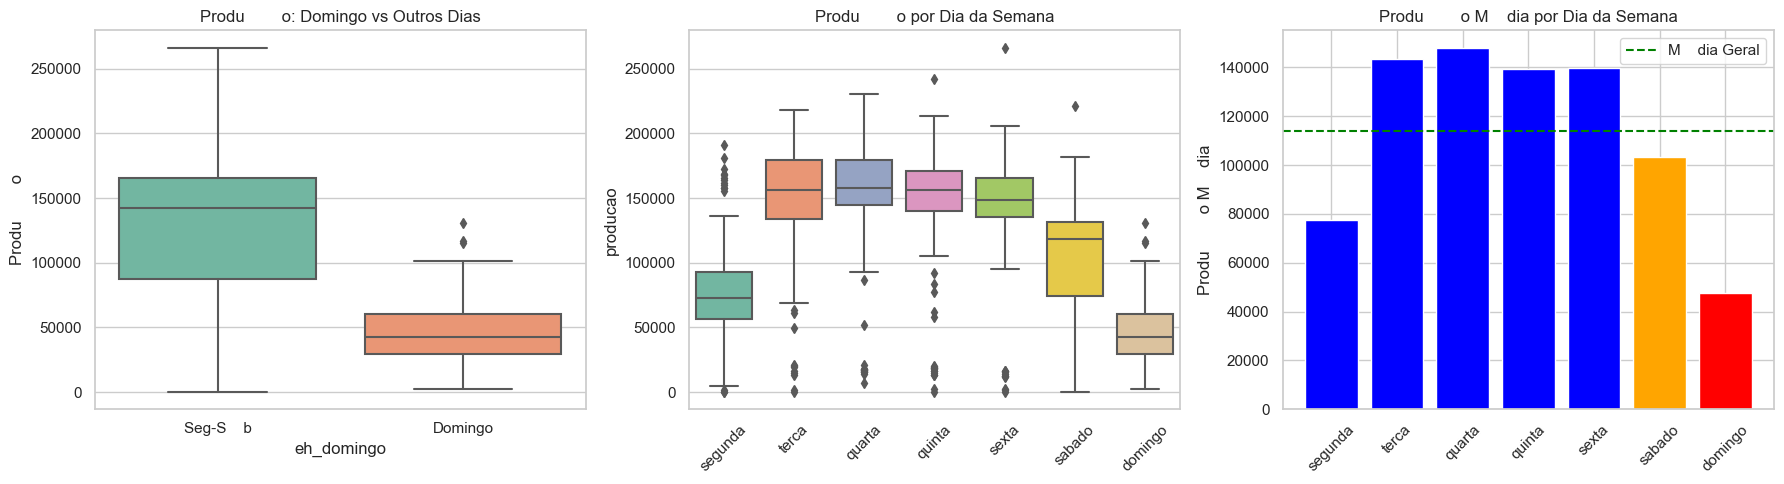

In [8]:
# =============================================================================
# AN    LISE ESTAT    STICA: DOMINGO vs OUTROS DIAS
# =============================================================================

from scipy import stats

# Estat    sticas descritivas
print("\n" + "="*60)
print("AN    LISE DE SAZONALIDADE - DOMINGO vs OUTROS DIAS")
print("="*60)

domingo_stats = df.groupby('eh_domingo')['producao'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
domingo_stats.index = ['Dias     teis/S    bado', 'Domingo']
display(domingo_stats)

# Teste t para verificar se domingo      estatisticamente diferente
producao_domingo = df[df['eh_domingo'] == 1]['producao']
producao_outros = df[df['eh_domingo'] == 0]['producao']

t_stat, p_value = stats.ttest_ind(producao_domingo, producao_outros)

print(f"\n          Teste t para Domingo vs Outros Dias:")
print(f"   Estat    stica t: {t_stat:.4f}")
print(f"   P-value: {p_value:.4e}")
print(f"   {'        Domingo TEM impacto SIGNIFICATIVO (p < 0.05)' if p_value < 0.05 else '       Domingo N    O tem impacto significativo'}")

# Cohen's d (tamanho do efeito)
cohens_d = (producao_domingo.mean() - producao_outros.mean()) / np.sqrt(
    ((len(producao_domingo)-1)*producao_domingo.std()**2 + 
     (len(producao_outros)-1)*producao_outros.std()**2) / 
    (len(producao_domingo) + len(producao_outros) - 2)
)
print(f"   Tamanho do efeito (Cohen's d): {cohens_d:.4f}")
print(f"   Interpreta        o: {'Grande' if abs(cohens_d) > 0.8 else 'M    dio' if abs(cohens_d) > 0.5 else 'Pequeno'}")

# Visualiza        o comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot: Domingo vs outros dias
sns.boxplot(x='eh_domingo', y='producao', data=df, ax=axes[0])
axes[0].set_xticklabels(['Seg-S    b', 'Domingo'])
axes[0].set_title('Produ        o: Domingo vs Outros Dias')
axes[0].set_ylabel('Produ        o')

# Distribui        o por dia da semana
ordem_dias = ['segunda', 'terca', 'quarta', 'quinta', 'sexta', 'sabado', 'domingo']
df_dia_semana = df.copy()
df_dia_semana['dia_nome'] = df_dia_semana['dia_semana'].map(dict(enumerate(ordem_dias)))
sns.boxplot(x='dia_nome', y='producao', data=df_dia_semana, order=ordem_dias, ax=axes[1])
axes[1].set_title('Produ        o por Dia da Semana')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# M    dia por dia da semana
media_dia = df_dia_semana.groupby('dia_nome')['producao'].mean().reindex(ordem_dias)
axes[2].bar(range(7), media_dia.values, color=['blue']*5 + ['orange', 'red'])
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(ordem_dias, rotation=45)
axes[2].set_title('Produ        o M    dia por Dia da Semana')
axes[2].set_ylabel('Produ        o M    dia')
axes[2].axhline(y=df['producao'].mean(), color='green', linestyle='--', label='M    dia Geral')
axes[2].legend()

plt.tight_layout()
plt.show()


## 4.3. An    lise Detalhada de Impacto de Eventos

Vamos identificar e quantificar o impacto de cada evento na produ        o, criando m    tricas de compara        o entre dias com e sem evento.



AN    LISE DE IMPACTO DOS EVENTOS NA PRODU         O

          Total de eventos identificados: 10

          Top Eventos com Maior Impacto na Produ        o:


,evento,dias_com_evento,producao_media_com,producao_media_sem,diferenca_absoluta,diferenca_percentual,producao_std_com,producao_std_sem
7,semana_black_friday,5,214244.600000,113286.000000,100958.600000,89.118338,55661.540864,59784.895966
1,dia_dos_namorados,2,188701.000000,113829.721966,74871.278034,65.774805,31107.041518,60298.620120
0,dia_das_maes,2,40951.000000,114283.639017,-73332.639017,-64.167224,16370.936198,60313.343858
2,dia_dos_pais,2,54175.000000,114243.012289,-60068.012289,-52.579157,32159.216408,60348.559521
3,feriado_nacional,22,64304.181818,115793.754358,-51489.572540,-44.466623,47041.861668,60061.642283
6,ressaca_black_friday,14,139954.428571,113491.688576,26462.739996,23.316897,78227.914572,59863.304193
5,periodo_natal_pre,3,99663.333333,114125.478462,-14462.145128,-12.672144,53942.034688,60417.792897
4,liquidacao_janeiro,5,110681.200000,114085.100309,-3403.900309,-2.983650,52507.099755,60451.797033
8,vespera_feriado,19,111151.421053,114146.173502,-2994.752449,-2.623612,60160.662351,60411.727403
9,volta_as_aulas,114,116124.517544,113622.181818,2502.335726,2.202330,55390.925034,61399.483847


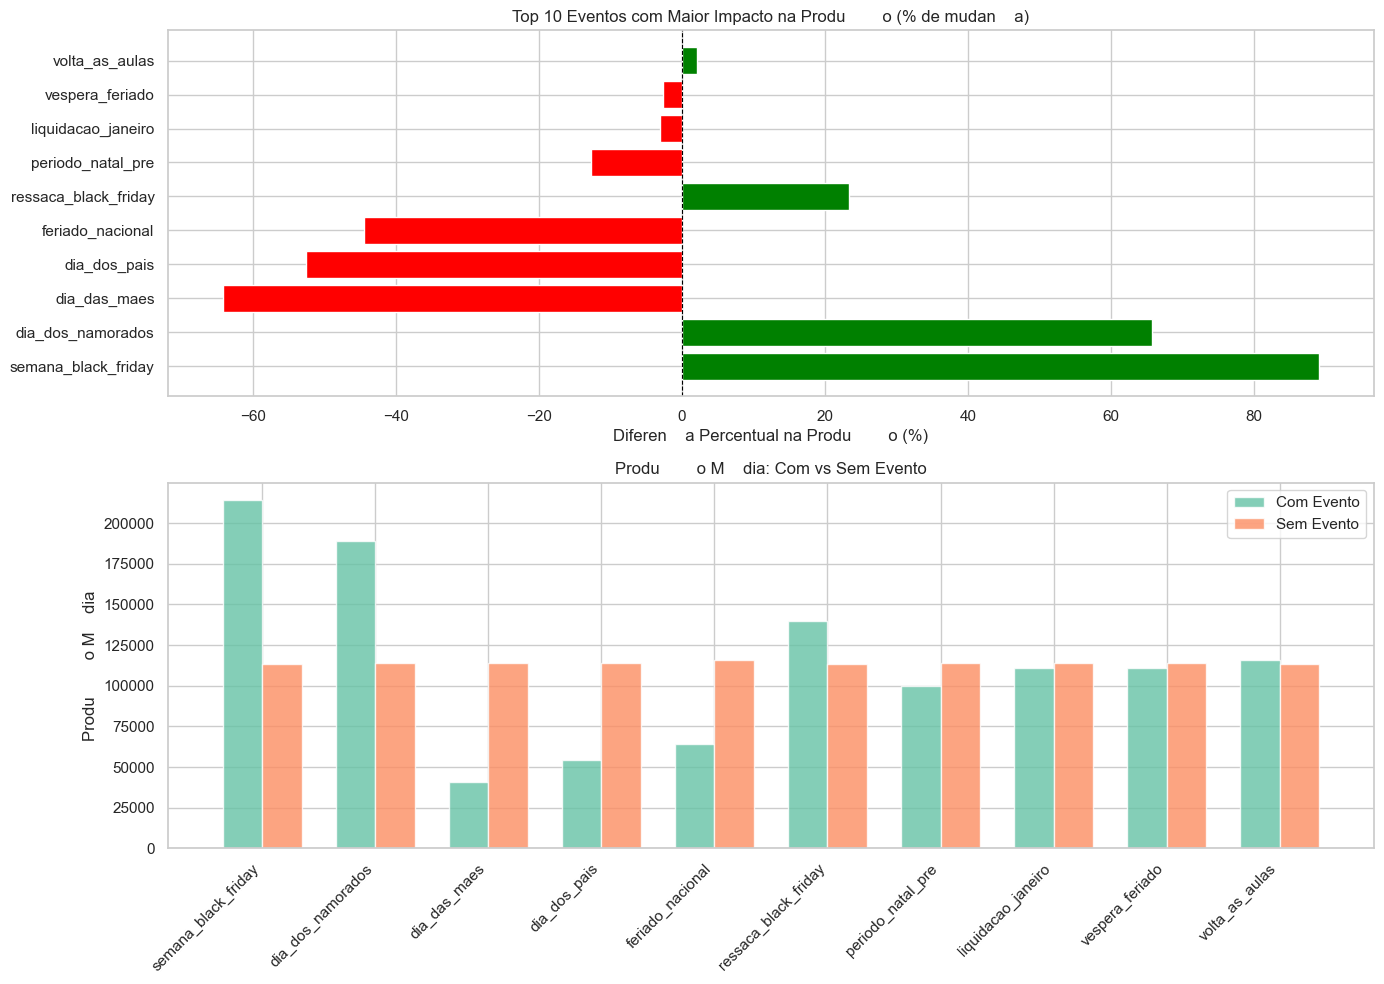


           Criando intera        es entre Top 5 eventos e domingo...
           Criada: evt_semana_black_friday_domingo
           Criada: evt_dia_dos_namorados_domingo
           Criada: evt_dia_das_maes_domingo
           Criada: evt_dia_dos_pais_domingo
           Criada: evt_feriado_nacional_domingo

        An    lise de 10 eventos conclu    da!


In [9]:
# =============================================================================
# AN    LISE DETALHADA DE IMPACTO DOS EVENTOS
# =============================================================================

print("\n" + "="*60)
print("AN    LISE DE IMPACTO DOS EVENTOS NA PRODU         O")
print("="*60)

# Identificar todas as colunas de eventos (colunas que come    am com 'evt_')
evento_cols = [c for c in df.columns if c.startswith('evt_')]

print(f"\n          Total de eventos identificados: {len(evento_cols)}")

if len(evento_cols) > 0:
    # Estat    sticas de produ        o com e sem cada evento
    impacto_eventos = []
    
    for evt_col in evento_cols:
        com_evento = df[df[evt_col] == 1]['producao']
        sem_evento = df[df[evt_col] == 0]['producao']
        
        if len(com_evento) > 0:
            impacto = {
                'evento': evt_col.replace('evt_', ''),
                'dias_com_evento': len(com_evento),
                'producao_media_com': com_evento.mean(),
                'producao_media_sem': sem_evento.mean(),
                'diferenca_absoluta': com_evento.mean() - sem_evento.mean(),
                'diferenca_percentual': ((com_evento.mean() - sem_evento.mean()) / sem_evento.mean() * 100) if sem_evento.mean() != 0 else 0,
                'producao_std_com': com_evento.std(),
                'producao_std_sem': sem_evento.std()
            }
            impacto_eventos.append(impacto)
    
    if impacto_eventos:
        df_impacto = pd.DataFrame(impacto_eventos).sort_values('diferenca_percentual', key=abs, ascending=False)
        
        print("\n          Top Eventos com Maior Impacto na Produ        o:")
        display(df_impacto.head(15))
        
        # Visualizar impacto dos eventos mais relevantes
        top_eventos = df_impacto.head(10)
        
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Diferen    a percentual
        colors = ['red' if x < 0 else 'green' for x in top_eventos['diferenca_percentual']]
        axes[0].barh(top_eventos['evento'], top_eventos['diferenca_percentual'], color=colors)
        axes[0].set_xlabel('Diferen    a Percentual na Produ        o (%)')
        axes[0].set_title('Top 10 Eventos com Maior Impacto na Produ        o (% de mudan    a)')
        axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        
        # Compara        o m    dias (com vs sem evento)
        x_pos = np.arange(len(top_eventos))
        width = 0.35
        axes[1].bar(x_pos - width/2, top_eventos['producao_media_com'], width, label='Com Evento', alpha=0.8)
        axes[1].bar(x_pos + width/2, top_eventos['producao_media_sem'], width, label='Sem Evento', alpha=0.8)
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(top_eventos['evento'], rotation=45, ha='right')
        axes[1].set_ylabel('Produ        o M    dia')
        axes[1].set_title('Produ        o M    dia: Com vs Sem Evento')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Criar intera        es entre eventos mais importantes e domingo
        print("\n           Criando intera        es entre Top 5 eventos e domingo...")
        top_5_eventos = df_impacto.head(5)['evento'].tolist()
        for evt in top_5_eventos:
            evt_col_name = f'evt_{evt}'
            if evt_col_name in df.columns:
                df[f'{evt_col_name}_domingo'] = df[evt_col_name] * df['eh_domingo']
                print(f"           Criada: {evt_col_name}_domingo")
        
        print(f"\n        An    lise de {len(impacto_eventos)} eventos conclu    da!")
    else:
        print("             Nenhum evento com dados encontrado.")
else:
    print("             Nenhuma coluna de evento encontrada (evt_*).")
    print("   Verificando se existe coluna 'evento' para convers    o...")
    
    # Tentar identificar e converter coluna 'evento' se existir
    if 'evento' in df.columns:
        print("           Coluna 'evento' encontrada. Convertendo para dummies...")
        df = pd.get_dummies(df, columns=['evento'], prefix='evt', drop_first=False)
        evento_cols = [c for c in df.columns if c.startswith('evt_')]
        print(f"           {len(evento_cols)} eventos convertidos em dummies!")
        
        # Reexecutar an    lise com novos eventos
        print("\n   Reexecutando an    lise de impacto...")
    else:
        print("          Coluna 'evento' n    o encontrada no dataframe.")


## 4.4. An    lise de Feriados Espec    ficos

Vamos analisar o impacto de cada tipo de feriado na produ        o.



AN    LISE DE IMPACTO DE FERIADOS ESPEC    FICOS

           Total de feriados identificados: 13
   Total de dias com feriado: 22


,count,mean,std,min,max
nome_feriado,,,,,
Proclamação da República,1,161119.0,NaN,161119.0,161119.0
Consciência Negra,1,150497.0,NaN,150497.0,150497.0
Finados,1,102984.0,NaN,102984.0,102984.0
Corpus Christi,2,101975.0,14270.829058,91884.0,112066.0
Dia do Trabalhador,2,82084.0,6690.644364,77353.0,86815.0
Independência do Brasil,2,59779.5,50066.695642,24377.0,95182.0
Carnaval (Terça),2,56559.5,9911.515752,49551.0,63568.0
Sexta-feira Santa,2,53704.0,75948.925154,0.0,107408.0
Confraternização Universal,2,47133.0,66542.990750,80.0,94186.0


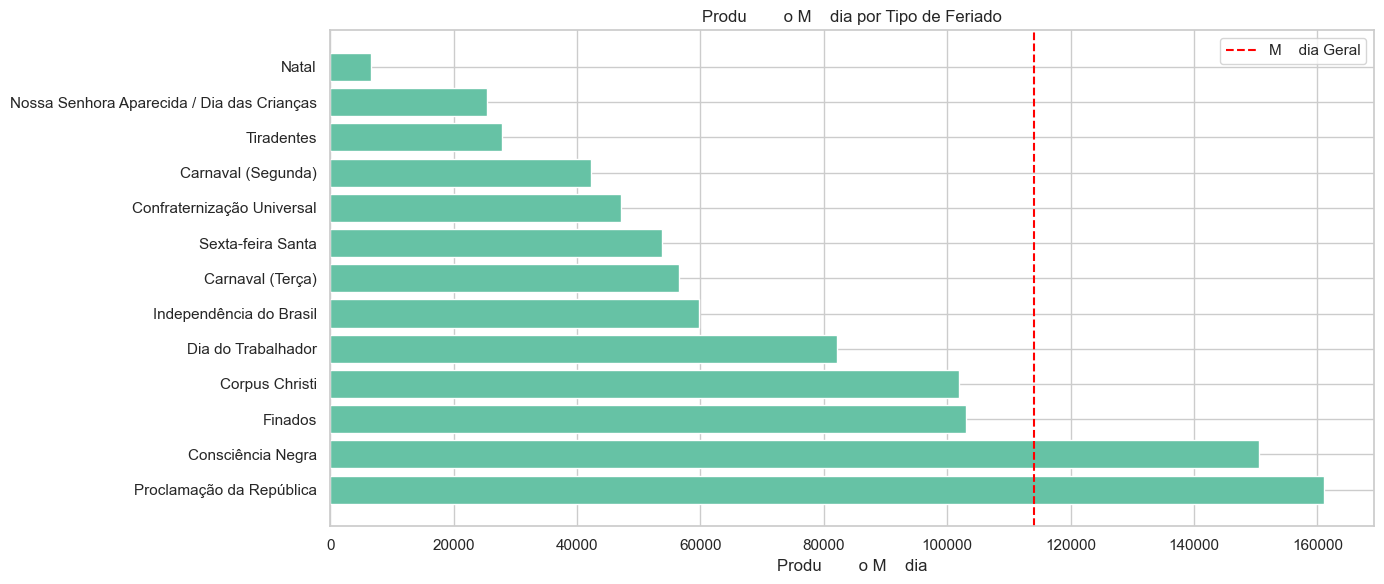

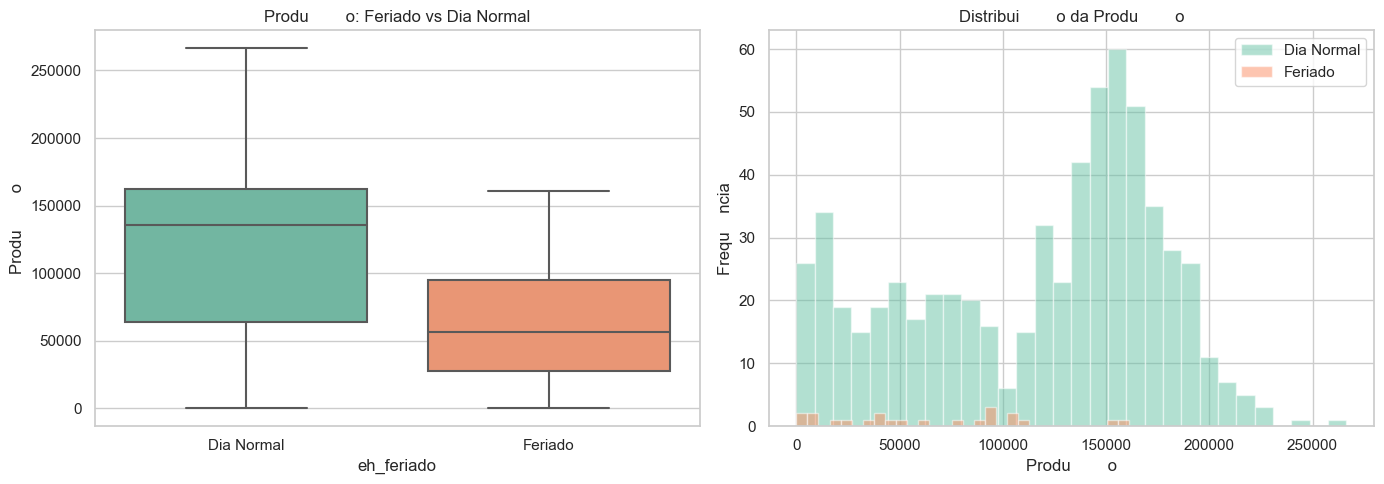


        An    lise de feriados espec    ficos conclu    da!


In [10]:
# =============================================================================
# AN    LISE DE IMPACTO DE FERIADOS ESPEC    FICOS
# =============================================================================

if 'nome_feriado' in df.columns:
    print("\n" + "="*60)
    print("AN    LISE DE IMPACTO DE FERIADOS ESPEC    FICOS")
    print("="*60)
    
    # Filtrar apenas feriados (excluir valores nulos/NaN)
    feriados_df = df[df['eh_feriado'] == 1].copy()
    
    if len(feriados_df) > 0:
        feriados_stats = feriados_df.groupby('nome_feriado')['producao'].agg(['count', 'mean', 'std', 'min', 'max'])
        feriados_stats = feriados_stats.sort_values('mean', ascending=False)
        
        print(f"\n           Total de feriados identificados: {len(feriados_stats)}")
        print(f"   Total de dias com feriado: {len(feriados_df)}")
        
        display(feriados_stats)
        
        # Visualizar impacto
        if len(feriados_stats) > 0:
            plt.figure(figsize=(14, 6))
            plt.barh(feriados_stats.index, feriados_stats['mean'])
            plt.xlabel('Produ        o M    dia')
            plt.title('Produ        o M    dia por Tipo de Feriado')
            plt.axvline(x=df['producao'].mean(), color='red', linestyle='--', label='M    dia Geral')
            plt.legend()
            plt.tight_layout()
            plt.show()
            
            # Compara        o visual: feriado vs n    o-feriado
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Boxplot geral
            sns.boxplot(x='eh_feriado', y='producao', data=df, ax=axes[0])
            axes[0].set_xticklabels(['Dia Normal', 'Feriado'])
            axes[0].set_title('Produ        o: Feriado vs Dia Normal')
            axes[0].set_ylabel('Produ        o')
            
            # Distribui        o
            df[df['eh_feriado'] == 0]['producao'].hist(bins=30, alpha=0.5, label='Dia Normal', ax=axes[1])
            df[df['eh_feriado'] == 1]['producao'].hist(bins=30, alpha=0.5, label='Feriado', ax=axes[1])
            axes[1].set_xlabel('Produ        o')
            axes[1].set_ylabel('Frequ    ncia')
            axes[1].set_title('Distribui        o da Produ        o')
            axes[1].legend()
            
            plt.tight_layout()
            plt.show()
            
            print("\n        An    lise de feriados espec    ficos conclu    da!")
    else:
        print("             Nenhum feriado encontrado nos dados.")
else:
    print("\n             Coluna 'nome_feriado' n    o encontrada no dataframe.")


## 5. An    lise Explorat    ria das S    ries Temporais

Vamos visualizar a s    rie temporal de produ        o, identificar tend    ncias, sazonalidades, outliers e analisar visualmente o impacto de eventos e vari    veis ex    genas.


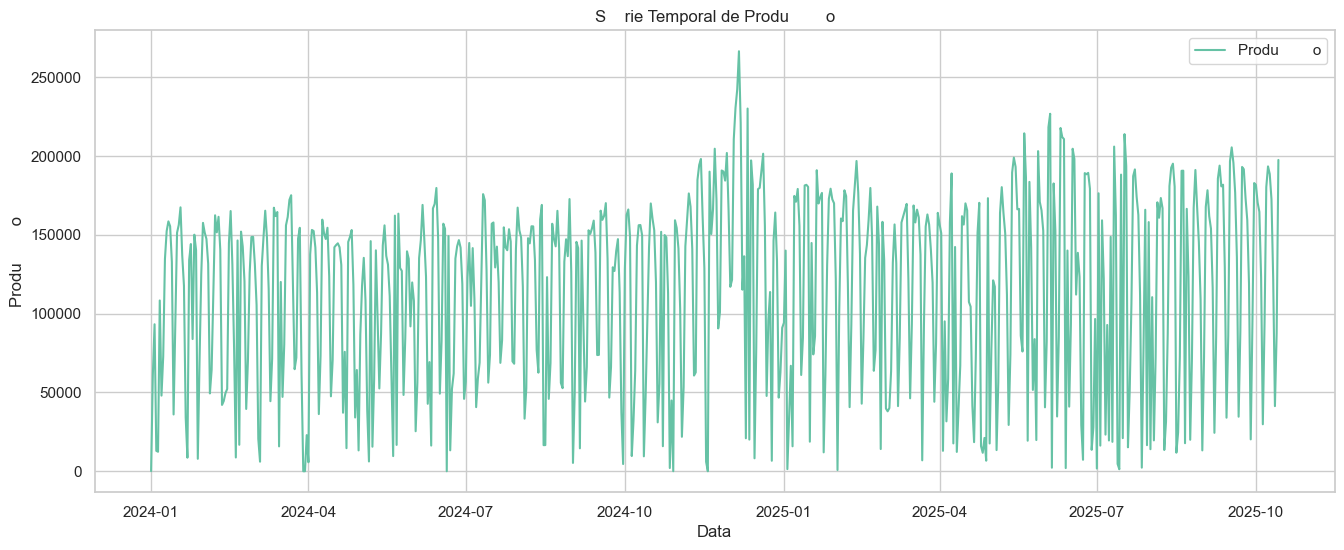

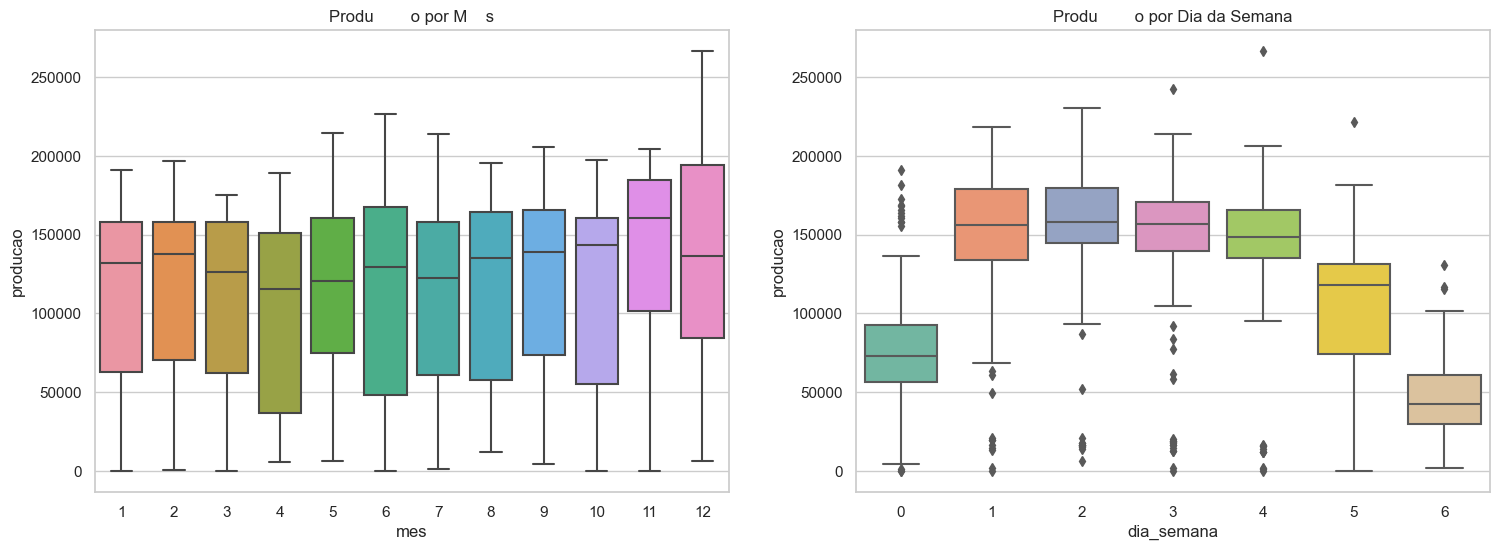

In [11]:
# Plot da s    rie temporal de produ        o
plt.figure(figsize=(16,6))
plt.plot(df['data'], df['producao'], label='Produ        o')
plt.title('S    rie Temporal de Produ        o')
plt.xlabel('Data')
plt.ylabel('Produ        o')
plt.legend()
plt.show()

# Boxplot por m    s e dia da semana
fig, axes = plt.subplots(1, 2, figsize=(18,6))
sns.boxplot(x='mes', y='producao', data=df, ax=axes[0])
axes[0].set_title('Produ        o por M    s')
sns.boxplot(x='dia_semana', y='producao', data=df, ax=axes[1])
axes[1].set_title('Produ        o por Dia da Semana')
plt.show()

# Visualizar impacto de eventos (se houver)
if any(['evento' in c for c in df.columns]):
    evento_cols = [c for c in df.columns if c.startswith('evento_')]
    for col in evento_cols:
        plt.figure(figsize=(14,4))
        sns.lineplot(x='data', y='producao', data=df, label='Produ        o')
        plt.scatter(df.loc[df[col]==1, 'data'], df.loc[df[col]==1, 'producao'], color='red', label=col, alpha=0.6)
        plt.title(f'Impacto do Evento: {col}')
        plt.legend()
        plt.show()


## 6. An    lise de Correla        o entre Produ        o, Vari    veis Ex    genas e Eventos

Vamos calcular e visualizar as correla        es entre produ        o, features criadas, vari    veis ex    genas e eventos para identificar rela        es relevantes.


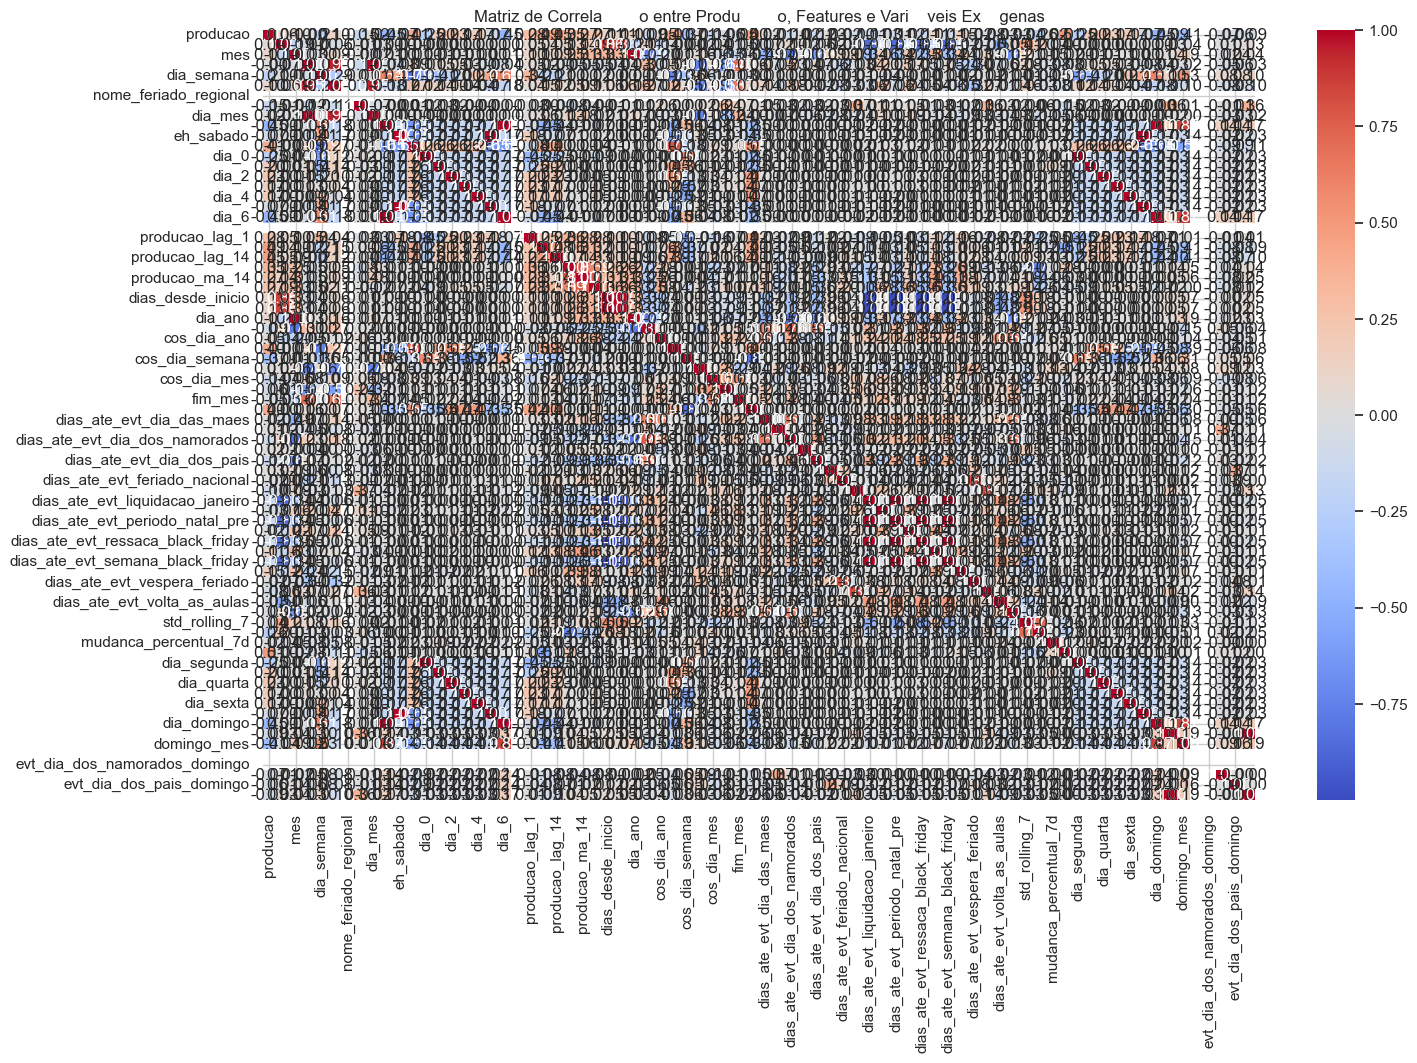

producao                           1.000000
aceleracao_producao                0.505112
producao_lag_7                     0.485542
producao_lag_14                    0.454381
eh_dia_util                        0.405403
                                     ...   
eh_domingo                        -0.449940
nome_feriado_regional                   NaN
feriado                                 NaN
evt_semana_black_friday_domingo         NaN
evt_dia_dos_namorados_domingo           NaN
Name: producao, Length: 76, dtype: float64

In [12]:
# Selecionar apenas colunas num    ricas para correla        o
corr_cols = df.select_dtypes(include=[np.number]).columns
corr = df[corr_cols].corr()

# Heatmap de correla        o
plt.figure(figsize=(16,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correla        o entre Produ        o, Features e Vari    veis Ex    genas')
plt.show()

# Correla        o da produ        o com as demais vari    veis
corr_producao = corr['producao'].sort_values(ascending=False)
display(corr_producao)


## 7. Sele        o de Features Relevantes

Vamos utilizar m    todos como feature importance do XGBoost, an    lise de autocorrela        o parcial (PACF) e testes estat    sticos para selecionar as colunas mais relevantes para os modelos.


[INFO] Skipping XGBoost feature importance (EDA) during automated run.


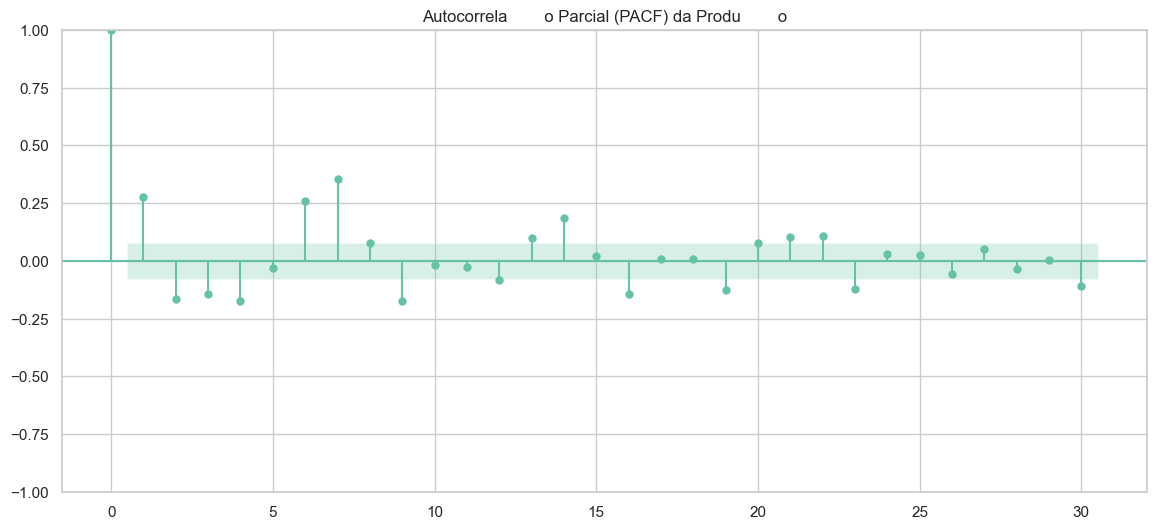

In [13]:
# Remover linhas com NaN gerados por lags/m    dias m    veis
# Garantir que as colunas de lags existam antes de selecionar
lag_cols = [c for c in ['producao_lag_1','producao_lag_7','producao_lag_14'] if c in df.columns]
features = df.dropna(subset=lag_cols).copy()

# Tratar valores nulos em nome_feriado
if 'nome_feriado' in features.columns:
    features['nome_feriado'] = features['nome_feriado'].fillna('SEM_FERIADO')

# Identificar colunas categ    ricas (object) para one-hot encoding
cat_cols = features.select_dtypes(include=['object']).columns.tolist()
# Remover coluna de data da lista de categ    ricas para n    o expandi-la
if 'data' in cat_cols:
    cat_cols.remove('data')
# Evitar expandir nomes com muitos nulos regionais
if 'nome_feriado_regional' in cat_cols:
    # Alto volume de NaN: descartar
    features = features.drop(columns=['nome_feriado_regional'])
    cat_cols = [c for c in cat_cols if c != 'nome_feriado_regional']

# One-hot encoding
features_encoded = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# Separar vari    veis explicativas e target
# Preservar coluna data para posterior separa        o temporal
X = features_encoded.drop(['producao'], axis=1).drop(columns=['data'])
X = X.fillna(0)
y = features_encoded['producao'].fillna(method='ffill').fillna(method='bfill')

    # Feature importance com XGBoost (habilitar categorical se necess    rio          j     codificamos)
print('[INFO] Skipping XGBoost feature importance (EDA) during automated run.')

# PACF para produ        o
plot_pacf(y, lags=30, method='ywm')
plt.title('Autocorrela        o Parcial (PACF) da Produ        o')
plt.show()

# Atualizar objeto global features para uso posterior (modelos SARIMAX/HoltWinters)
features = features_encoded








## 8. Valida        o Cruzada Temporal com Modelos Preditivos

Implementa        o de valida        o cruzada temporal com expans    o incremental, ajuste autom    tico de hiperpar    metros e compara        o entre XGBoost, SARIMAX e Holt-Winters.


In [14]:
# =============================================================================
# 8.1. CONFIGURA         O DE VALIDA         O CRUZADA TEMPORAL
# =============================================================================

from datetime import timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("\n" + "="*80)
print("CONFIGURA         O DE VALIDA         O CRUZADA TEMPORAL")
print("="*80)

# Preparar dados completos
df_model = features.copy()
df_model['data'] = df['data']
df_model = df_model.sort_values('data').reset_index(drop=True)

# Par    metros da valida        o cruzada
DATA_INICIAL = pd.to_datetime('2024-01-01')
INCREMENTO_DIAS = 7
JANELA_PREVISAO = 30

# Filtrar dados a partir da data inicial
df_model = df_model[df_model['data'] >= DATA_INICIAL].reset_index(drop=True)

print(f"\n          Configura        es:")
print(f"           Data inicial fixa: {DATA_INICIAL.strftime('%d/%m/%Y')}")
print(f"           Incremento de treino: {INCREMENTO_DIAS} dias")
print(f"           Janela de previs    o: {JANELA_PREVISAO} dias")
print(f"           Total de observa        es: {len(df_model)}")
print(f"           Per    odo: {df_model['data'].min().strftime('%d/%m/%Y')} a {df_model['data'].max().strftime('%d/%m/%Y')}")

# Identificar features para modelagem
exclude_cols = ['data', 'producao']
feature_cols = [c for c in df_model.columns if c not in exclude_cols]
# Colunas ex genas para SARIMAX (eventos e sazonalidade semanal/mensal)
# Apenas colunas num ricas e n o lags/m dias
exog_cols = [c for c in feature_cols if (not (c.startswith('producao_lag_') or c.startswith('producao_ma_'))) and (df_model[c].dtype.kind in 'iufc')]

print(f"\n          Features dispon    veis: {len(feature_cols)}")
print(f"   Top 10: {feature_cols[:10]}")

# Fun        o para calcular m    tricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1))) * 100
    return mae, rmse, mape

print("\n        Configura        o conclu    da!")





CONFIGURA         O DE VALIDA         O CRUZADA TEMPORAL

          Configura        es:
           Data inicial fixa: 01/01/2024
           Incremento de treino: 7 dias
           Janela de previs    o: 30 dias
           Total de observa        es: 639
           Per    odo: 15/01/2024 a 14/10/2025

          Features dispon    veis: 103
   Top 10: ['ano', 'mes', 'dia', 'dia_semana', 'semana_do_mes', 'nome_feriado_regional', 'eh_feriado', 'evt_dia_das_maes', 'evt_dia_dos_namorados', 'evt_dia_dos_pais']

        Configura        o conclu    da!


In [15]:
# =============================================================================
# 8.2. FUNCOES DE TUNING AUTOMATICO (ITERATIVO NAO-REGRESSIVO)
# =============================================================================

from sklearn.metrics import mean_squared_error


def _greedy_search(evaluate_fn, start_params, propose_fn, n_iter=20, patience=5):
    best_p = dict(start_params)
    best_s = evaluate_fn(best_p)
    no_imp = 0
    for _ in range(n_iter):
        cand = propose_fn(best_p)
        s = evaluate_fn(cand)
        if s < best_s - 1e-12:
            best_p, best_s = cand, s
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                break
    return best_p, best_s

# ---------- XGBoost ----------


def tune_xgboost_iter(X_train, y_train, X_val, y_val, start_params=None, n_iter=20):
    if start_params is None:
        start_params = {
            'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 4,
            'subsample': 0.9, 'colsample_bytree': 0.9
        }

    def evaluate(hp):
        model = xgb.XGBRegressor(**hp, random_state=42, objective='reg:squarederror')
        model.fit(X_train, y_train, verbose=False)
        pred = model.predict(X_val)
        return mean_squared_error(y_val, pred)

    def propose(hp):
        import numpy as _np, random
        p = dict(hp)
        p['n_estimators'] = int(max(100, min(1500, p['n_estimators'] + _np.random.randint(-150,151))))
        p['learning_rate'] = float(max(0.01, min(0.3, p['learning_rate'] * _np.random.uniform(0.85,1.15))))
        p['max_depth'] = int(max(2, min(12, p['max_depth'] + random.choice([-1,1]))))
        p['subsample'] = float(max(0.5, min(1.0, p['subsample'] * _np.random.uniform(0.9,1.1))))
        p['colsample_bytree'] = float(max(0.5, min(1.0, p['colsample_bytree'] * _np.random.uniform(0.9,1.1))))
        return p

    best_p, _ = _greedy_search(evaluate, start_params, propose, n_iter=n_iter)
    return best_p

# ---------- SARIMAX ----------


def tune_sarimax_iter(y_train, y_val, seasonal_period=7, start_cfg=None, n_iter=20):
    if start_cfg is None:
        start_cfg = {'p':1,'d':1,'q':1,'P':1,'D':1,'Q':1,'s':seasonal_period}

    bounds = {'p':(0,3),'d':(0,1),'q':(0,3),'P':(0,2),'D':(0,1),'Q':(0,2),'s':(seasonal_period, seasonal_period)}

    def evaluate(cfg):
        try:
            model = SARIMAX(y_train, order=(cfg['p'],cfg['d'],cfg['q']),
                            seasonal_order=(cfg['P'],cfg['D'],cfg['Q'],cfg['s']),
                            enforce_stationarity=False, enforce_invertibility=False)
            fit = model.fit(disp=False, maxiter=100)
            pred = fit.forecast(steps=len(y_val))
            return mean_squared_error(y_val, pred)
        except Exception:
            return float('inf')

    def propose(cfg):
        import numpy as _np
        c = dict(cfg)
        for k in ['p','q','P','Q']:
            c[k] = int(max(bounds[k][0], min(bounds[k][1], c[k] + _np.random.choice([-1,1]))))
        for k in ['d','D']:
            if _np.random.rand() < 0.3:
                c[k] = int(max(bounds[k][0], min(bounds[k][1], c[k] + _np.random.choice([-1,1]))))
        c['s'] = seasonal_period
        return c

    best_cfg, _ = _greedy_search(evaluate, start_cfg, propose, n_iter=n_iter)
    return best_cfg

# ---------- Holt-Winters ----------


def tune_hw_iter(y_train, y_val, seasonal_period=7, start_params=None, n_iter=20):
    if start_params is None:
        start_params = {'alpha':0.3,'beta':0.1,'gamma':0.3}

    def evaluate(hp):
        try:
            model = ExponentialSmoothing(y_train, seasonal_periods=seasonal_period,
                                         trend='add', seasonal='add', initialization_method='estimated')
            fit = model.fit(optimized=False, smoothing_level=hp['alpha'],
                            smoothing_trend=hp['beta'], smoothing_seasonal=hp['gamma'])
            pred = fit.forecast(steps=len(y_val))
            return mean_squared_error(y_val, pred)
        except Exception:
            return float('inf')

    def propose(hp):
        import numpy as _np
        p = dict(hp)
        for k in ['alpha','beta','gamma']:
            p[k] = float(max(0.001, min(0.999, p[k] * _np.random.uniform(0.8,1.2))))
        return p

    best, _ = _greedy_search(evaluate, start_params, propose, n_iter=n_iter)
    return best




INICIANDO VALIDA         O CRUZADA TEMPORAL

FOLD 1
           Treino: 01/01/2024 at     01/03/2024 (47 dias)
           Teste:  02/03/2024 at     31/03/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 791, 'learning_rate': 0.051212970767849655, 'max_depth': 2, 'subsample': 0.6043296073645966, 'colsample_bytree': 0.7185204545432272}
   MAE: 18528.46 | RMSE: 25093.99 | MAPE: 430903.33%

          Treinando SARIMAX...
   Melhor config: order=(1,0,3), seasonal_order=(0,1,1,7)
   MAE: 97926.76 | RMSE: 115243.38 | MAPE: 77769.34%

          Treinando Holt-Winters...
   MAE: 37831.83 | RMSE: 54438.24 | MAPE: 980222.94%


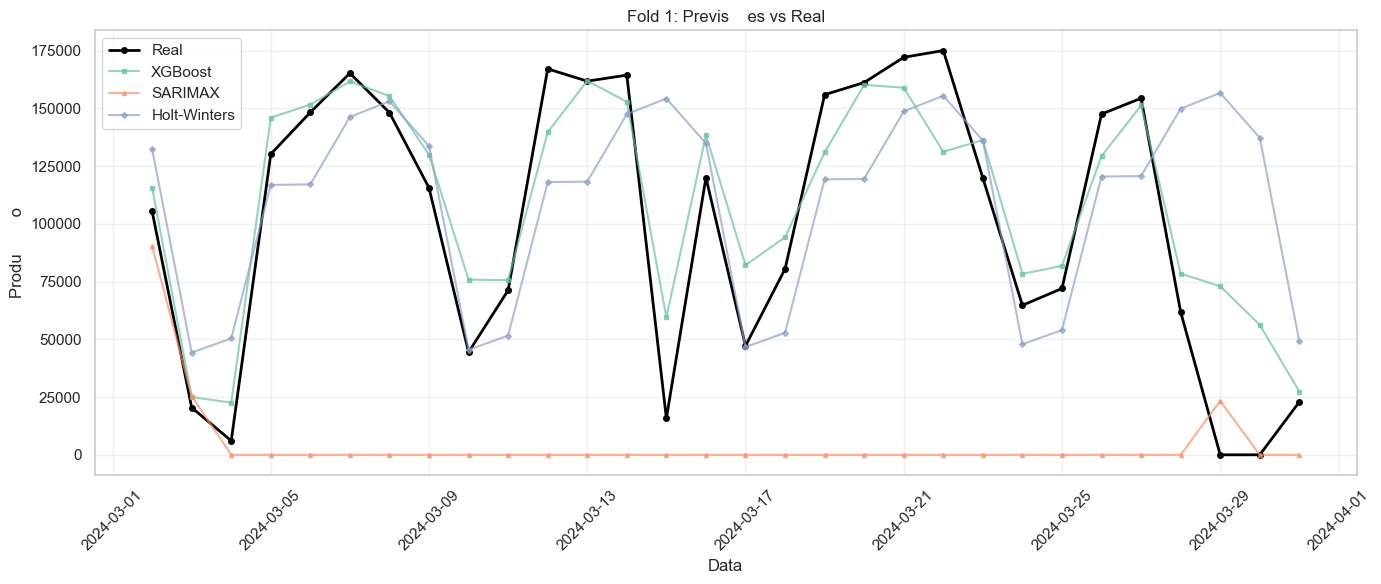


FOLD 2
           Treino: 01/01/2024 at     08/03/2024 (54 dias)
           Teste:  09/03/2024 at     07/04/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 827, 'learning_rate': 0.046785246011303995, 'max_depth': 2, 'subsample': 0.5899843436287275, 'colsample_bytree': 0.7542412502220249}
   MAE: 14921.18 | RMSE: 21392.27 | MAPE: 364943.74%

          Treinando SARIMAX...
   Melhor config: order=(0,0,2), seasonal_order=(1,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 35463.17 | RMSE: 53618.95 | MAPE: 992459.04%


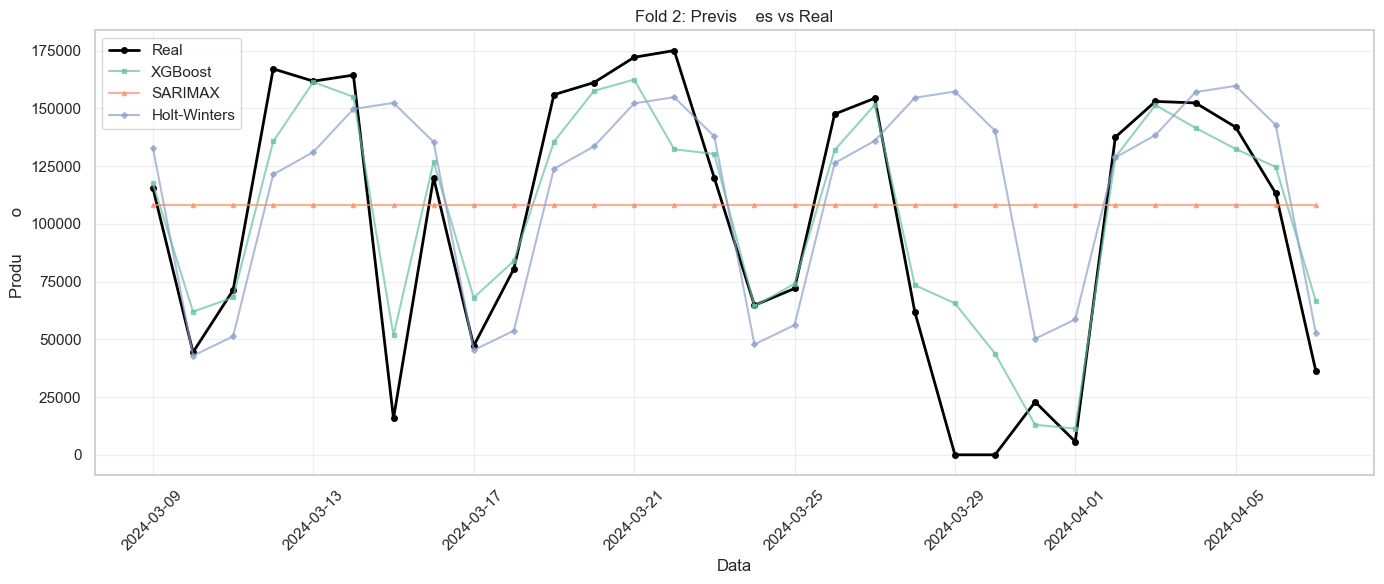


FOLD 3
           Treino: 01/01/2024 at     15/03/2024 (61 dias)
           Teste:  16/03/2024 at     14/04/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 725, 'learning_rate': 0.04570726172032727, 'max_depth': 4, 'subsample': 0.630038315206538, 'colsample_bytree': 0.7921691941854216}
   MAE: 13446.62 | RMSE: 18075.84 | MAPE: 230805.72%

          Treinando SARIMAX...
   Melhor config: order=(0,0,2), seasonal_order=(0,1,0,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 33280.81 | RMSE: 45006.09 | MAPE: 872507.66%


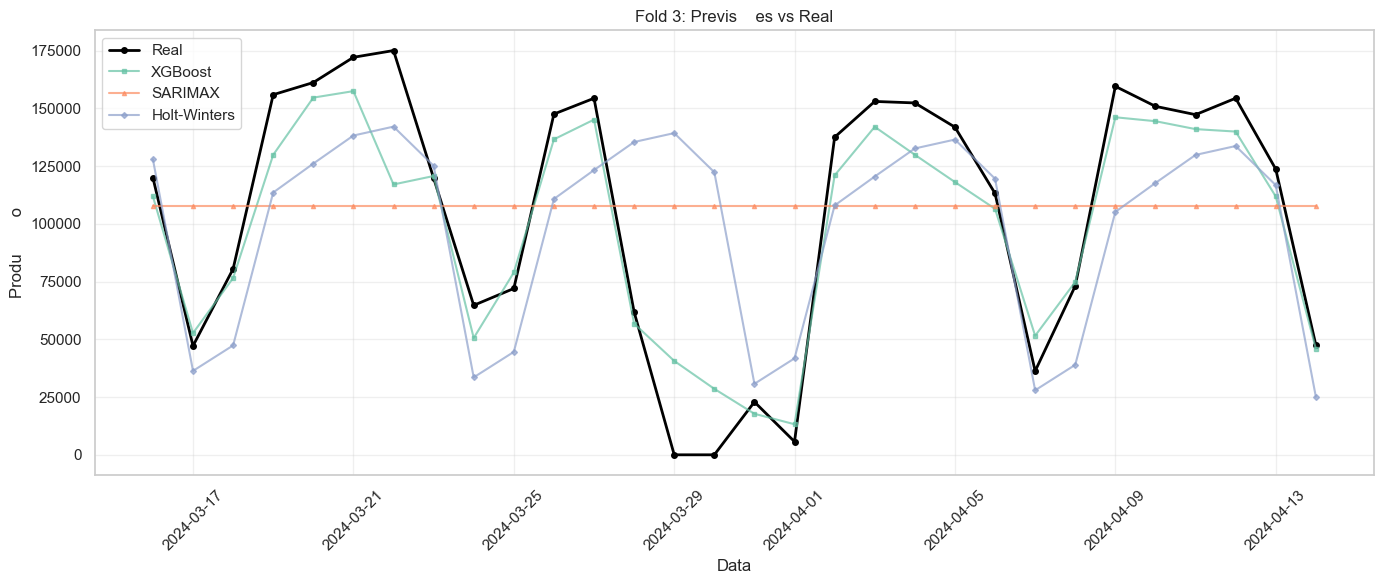


FOLD 4
           Treino: 01/01/2024 at     22/03/2024 (68 dias)
           Teste:  23/03/2024 at     21/04/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 753, 'learning_rate': 0.04633526323687224, 'max_depth': 6, 'subsample': 0.6347077968913559, 'colsample_bytree': 0.7349302943156386}
   MAE: 9774.20 | RMSE: 13852.83 | MAPE: 222184.60%

          Treinando SARIMAX...
   Melhor config: order=(0,0,3), seasonal_order=(1,1,1,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 53499.91 | RMSE: 66961.49 | MAPE: 1125989.27%


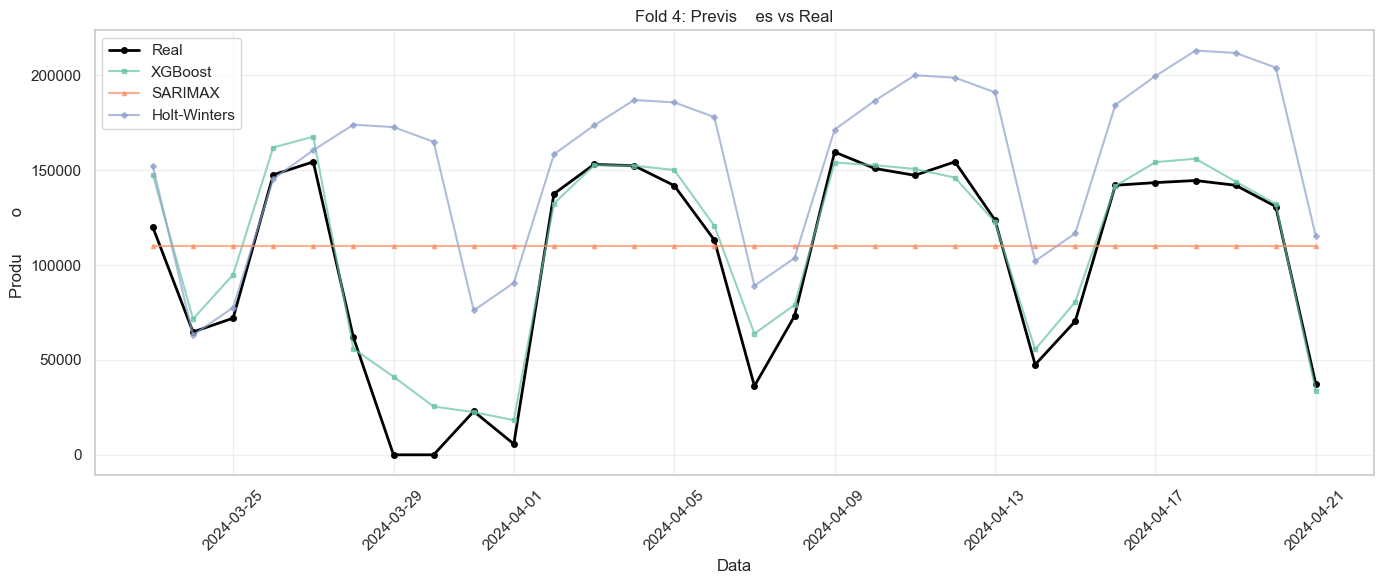


FOLD 5
           Treino: 01/01/2024 at     29/03/2024 (75 dias)
           Teste:  30/03/2024 at     28/04/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 743, 'learning_rate': 0.044931616526822524, 'max_depth': 7, 'subsample': 0.6260048442773697, 'colsample_bytree': 0.7017032297992877}
   MAE: 6839.99 | RMSE: 8700.54 | MAPE: 44980.94%

          Treinando SARIMAX...
   Melhor config: order=(1,0,3), seasonal_order=(2,1,0,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 21496.43 | RMSE: 34960.82 | MAPE: 428048.94%


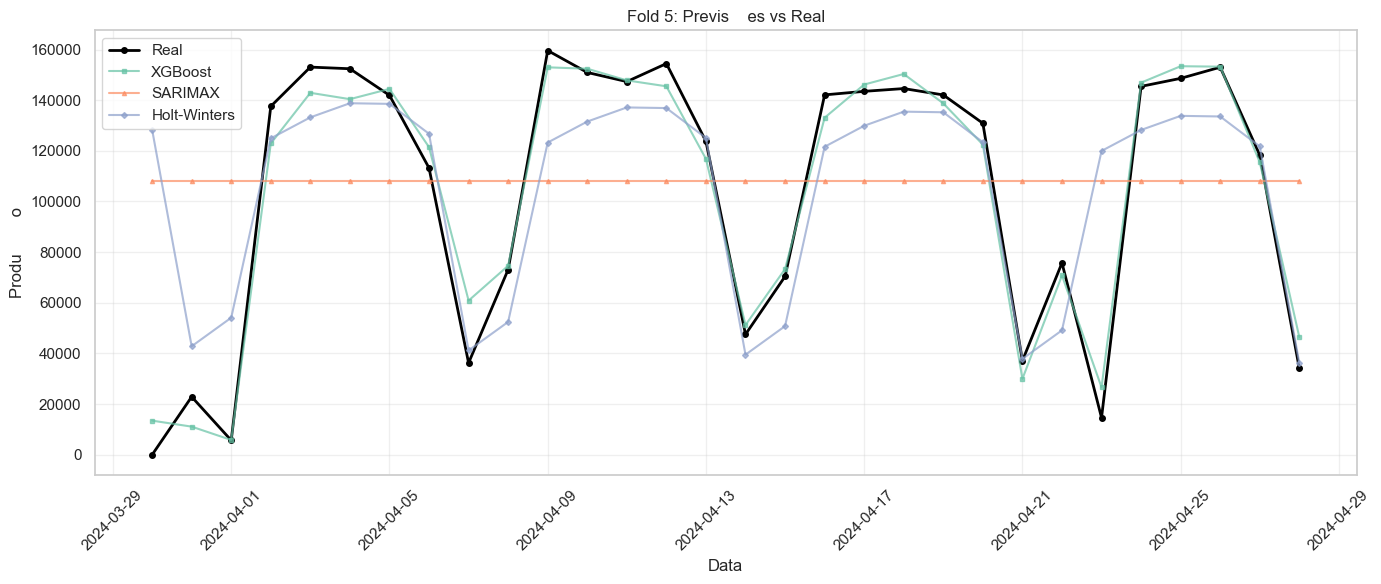


FOLD 6
           Treino: 01/01/2024 at     05/04/2024 (82 dias)
           Teste:  06/04/2024 at     05/05/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 902, 'learning_rate': 0.04823910156957408, 'max_depth': 4, 'subsample': 0.6012890873736403, 'colsample_bytree': 0.8148463689951111}
          Erro no XGBoost: [16:54:19] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(1,0,2), seasonal_order=(2,0,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 30390.22 | RMSE: 36236.42 | MAPE: 69.76%


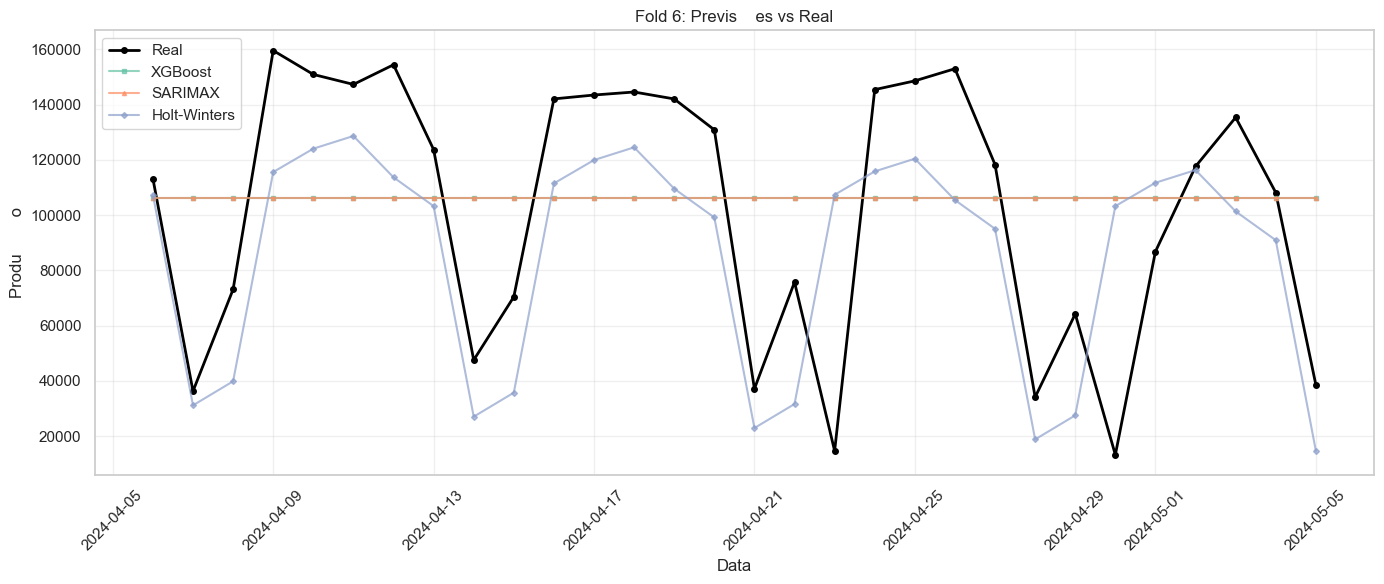


FOLD 7
           Treino: 01/01/2024 at     12/04/2024 (89 dias)
           Teste:  13/04/2024 at     12/05/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 1018, 'learning_rate': 0.04701937741268416, 'max_depth': 5, 'subsample': 0.6241337067898974, 'colsample_bytree': 0.770568174302527}
          Erro no XGBoost: [16:54:35] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,1), seasonal_order=(2,0,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 29722.32 | RMSE: 43626.10 | MAPE: 120.16%


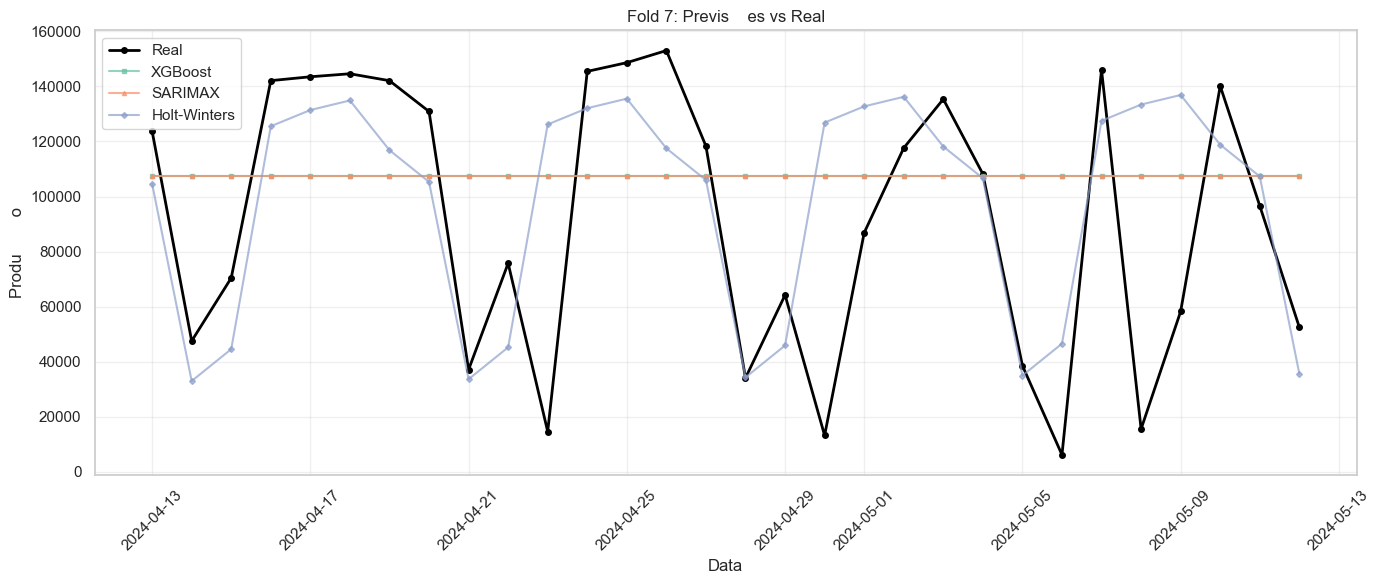


FOLD 8
           Treino: 01/01/2024 at     19/04/2024 (96 dias)
           Teste:  20/04/2024 at     19/05/2024 (30 dias)

          Treinando XGBoost...
   Melhores parametros: {'n_estimators': 861, 'learning_rate': 0.05765243280215941, 'max_depth': 5, 'subsample': 0.6633752377000218, 'colsample_bytree': 0.7046944881961927}
          Erro no XGBoost: [16:54:50] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,1), seasonal_order=(2,0,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 28681.81 | RMSE: 47836.91 | MAPE: 136.54%


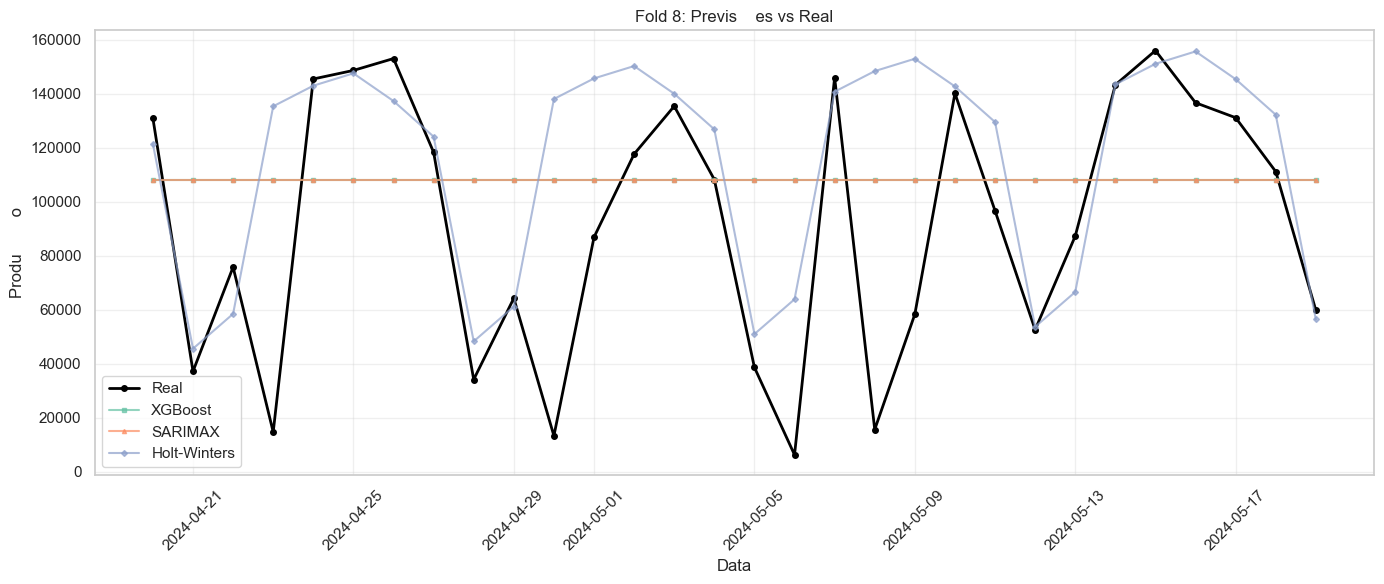


FOLD 9
           Treino: 01/01/2024 at     26/04/2024 (103 dias)
           Teste:  27/04/2024 at     26/05/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:54:53] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(1,0,2), seasonal_order=(1,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 31060.93 | RMSE: 48048.98 | MAPE: 147.74%


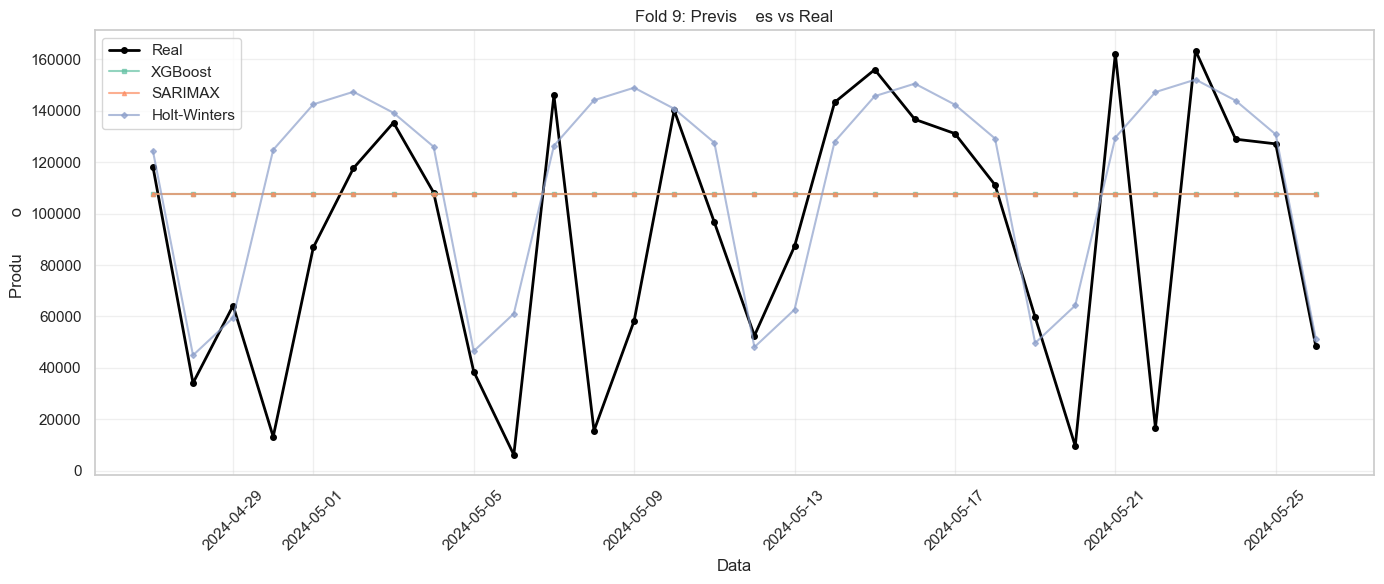


FOLD 10
           Treino: 01/01/2024 at     03/05/2024 (110 dias)
           Teste:  04/05/2024 at     02/06/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:54:58] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(0,0,3), seasonal_order=(0,1,1,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 29118.52 | RMSE: 41275.01 | MAPE: 109.25%


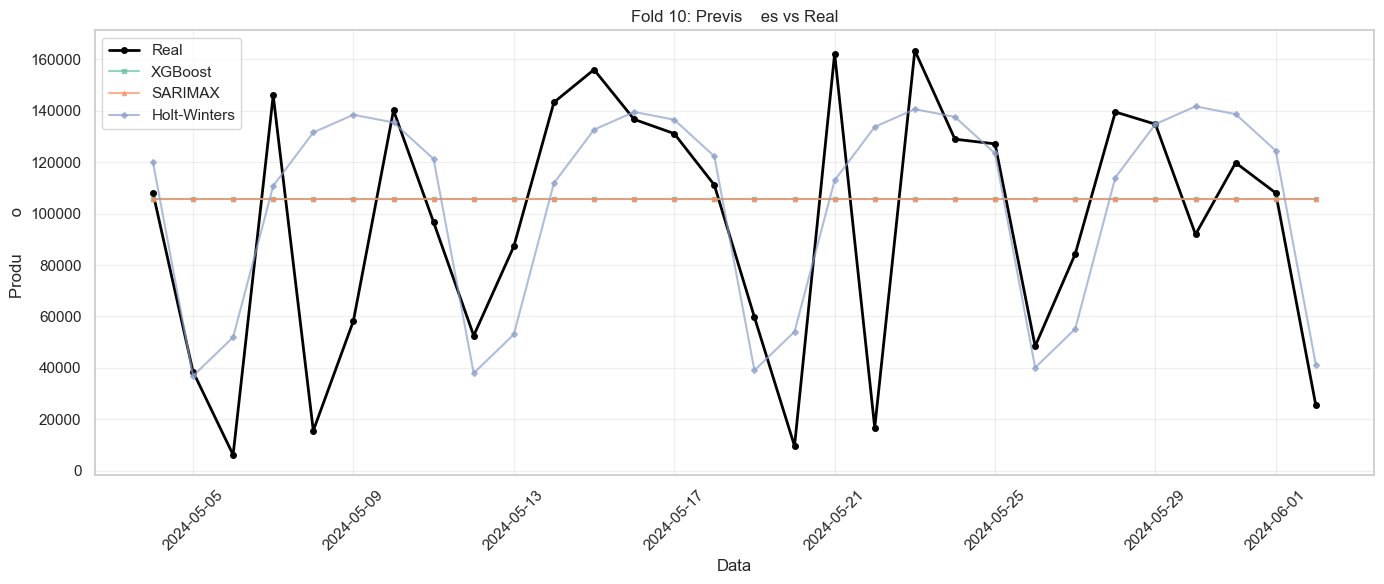


FOLD 11
           Treino: 01/01/2024 at     10/05/2024 (117 dias)
           Teste:  11/05/2024 at     09/06/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:01] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(1,0,3), seasonal_order=(1,0,0,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 31321.34 | RMSE: 37131.21 | MAPE: 54.59%


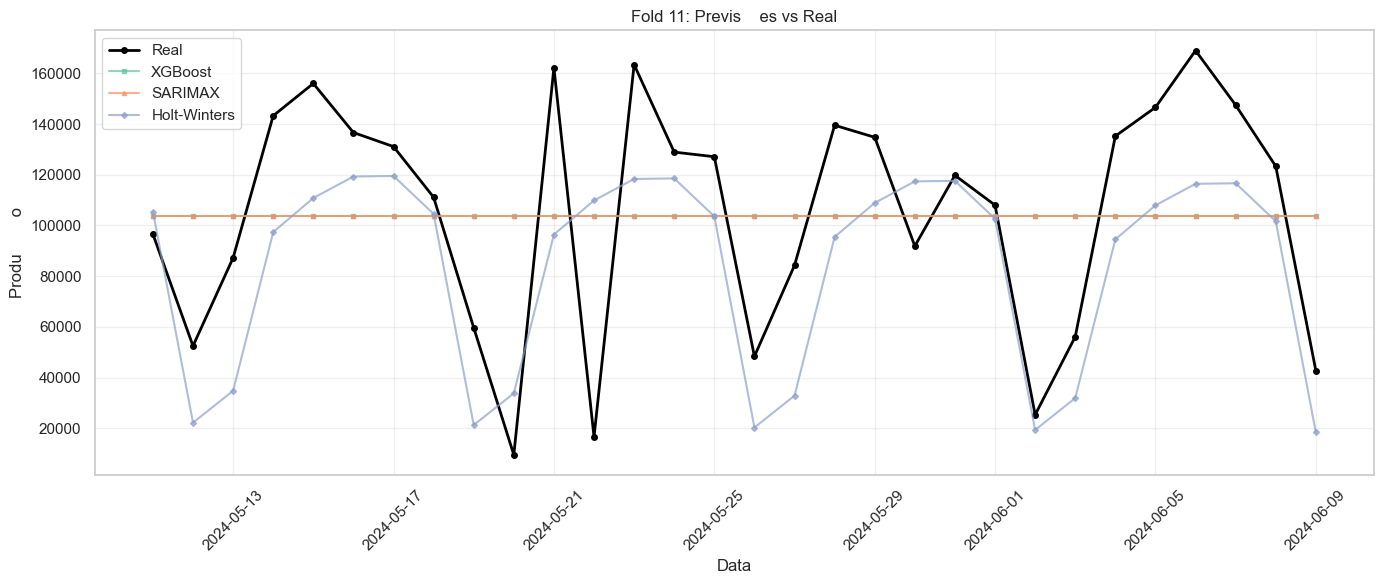


FOLD 12
           Treino: 01/01/2024 at     17/05/2024 (124 dias)
           Teste:  18/05/2024 at     16/06/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:05] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,2), seasonal_order=(1,0,0,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 31128.70 | RMSE: 38661.81 | MAPE: 71.33%


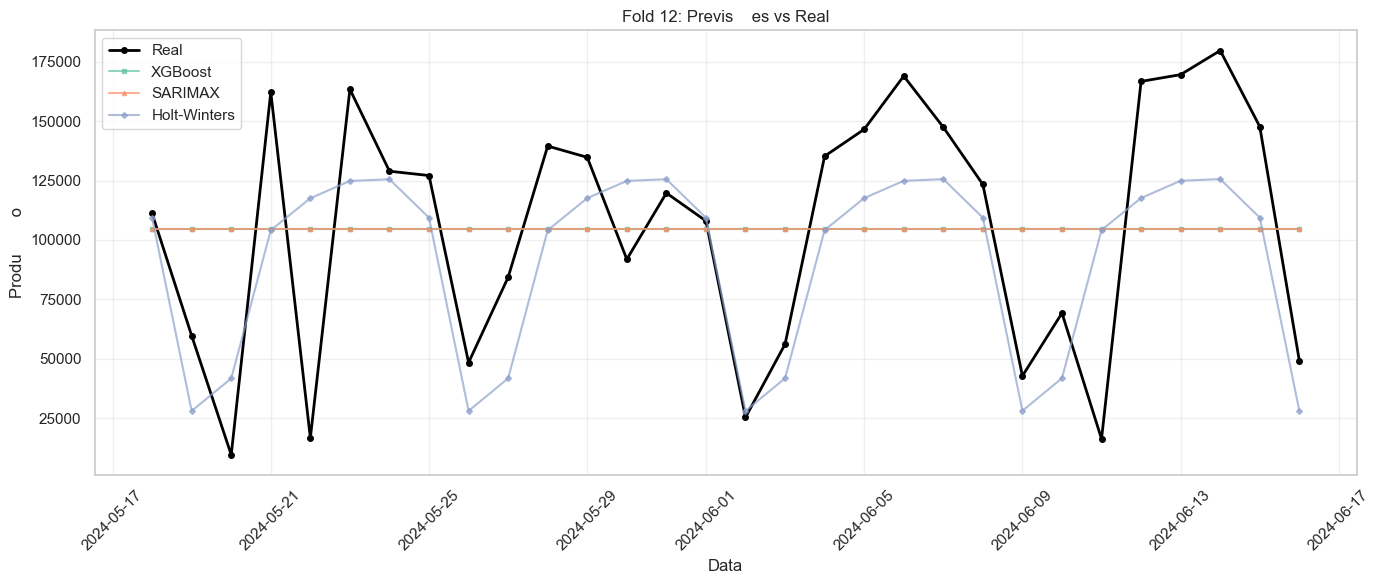


FOLD 13
           Treino: 01/01/2024 at     24/05/2024 (131 dias)
           Teste:  25/05/2024 at     23/06/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:11] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,3), seasonal_order=(1,0,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 37259.25 | RMSE: 45754.50 | MAPE: 414562.61%


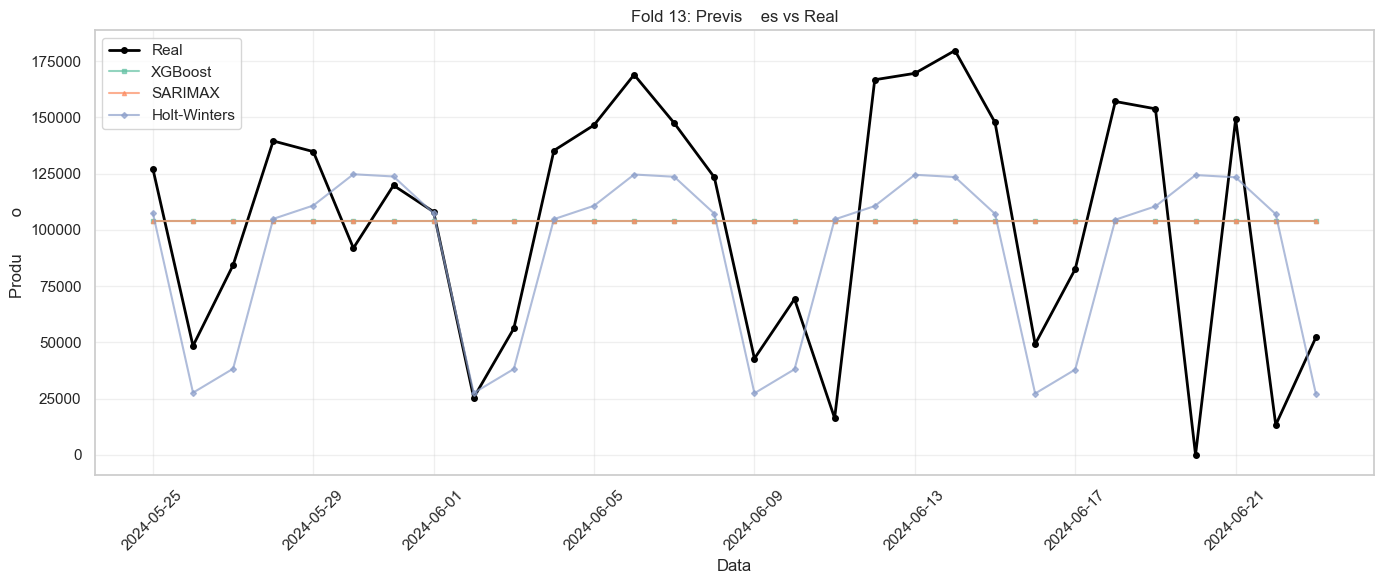


FOLD 14
           Treino: 01/01/2024 at     31/05/2024 (138 dias)
           Teste:  01/06/2024 at     30/06/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:20] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,3), seasonal_order=(1,0,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 33319.12 | RMSE: 43579.65 | MAPE: 422260.24%


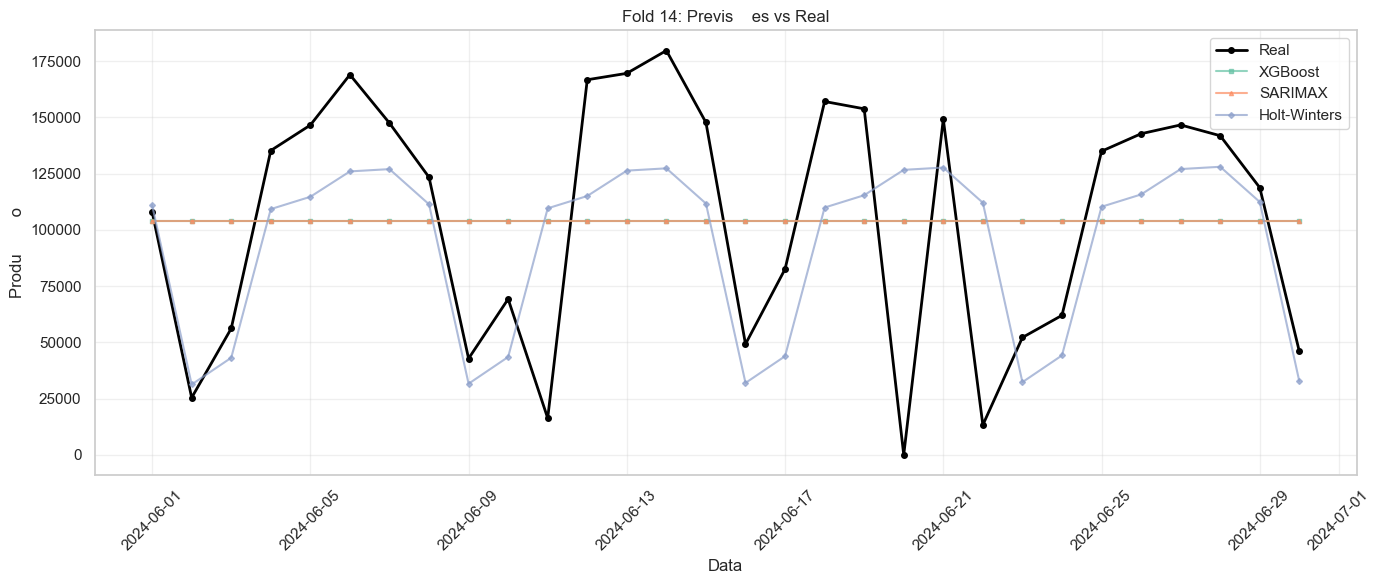


FOLD 15
           Treino: 01/01/2024 at     07/06/2024 (145 dias)
           Teste:  08/06/2024 at     07/07/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:29] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(1,1,1,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 26298.84 | RMSE: 41853.10 | MAPE: 456686.68%


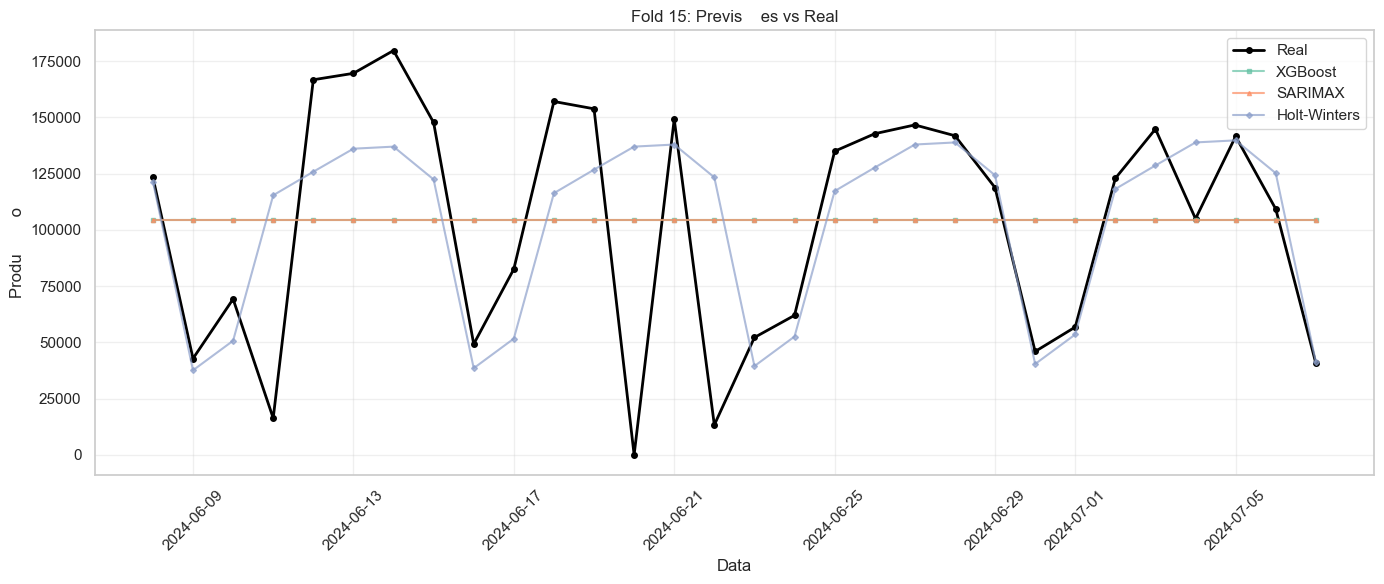


FOLD 16
           Treino: 01/01/2024 at     14/06/2024 (152 dias)
           Teste:  15/06/2024 at     14/07/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:40] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(0,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 22106.06 | RMSE: 39155.74 | MAPE: 483061.88%


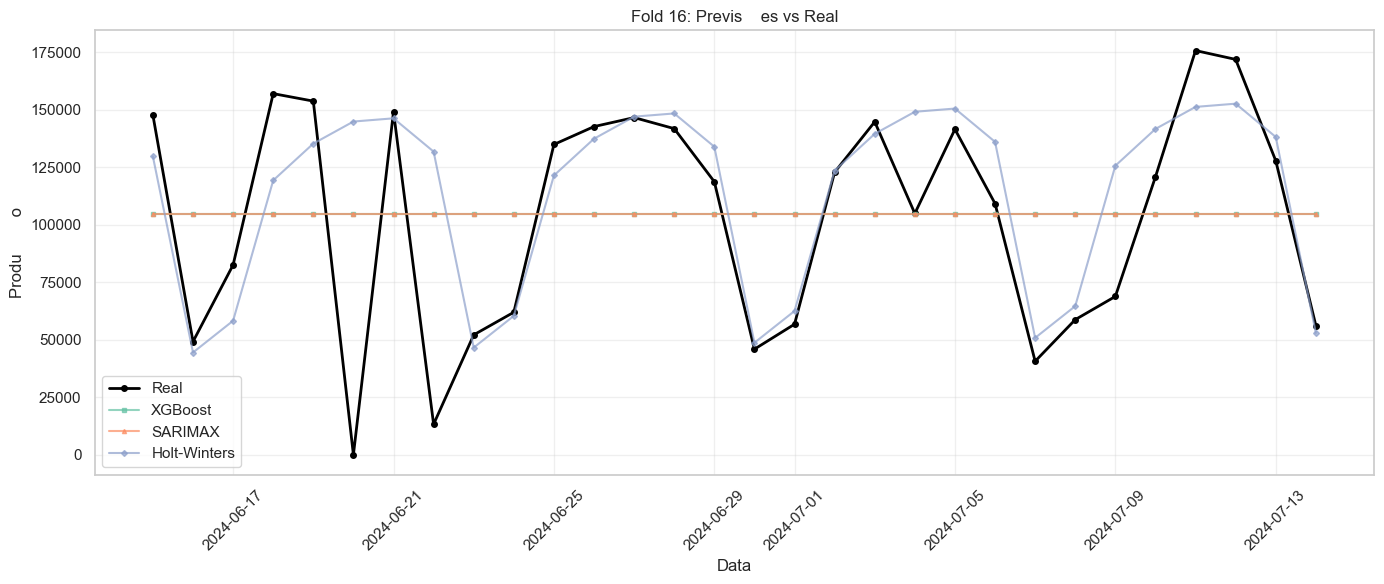


FOLD 17
           Treino: 01/01/2024 at     21/06/2024 (159 dias)
           Teste:  22/06/2024 at     21/07/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:55:50] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,2), seasonal_order=(2,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 16519.23 | RMSE: 27320.54 | MAPE: 40.61%


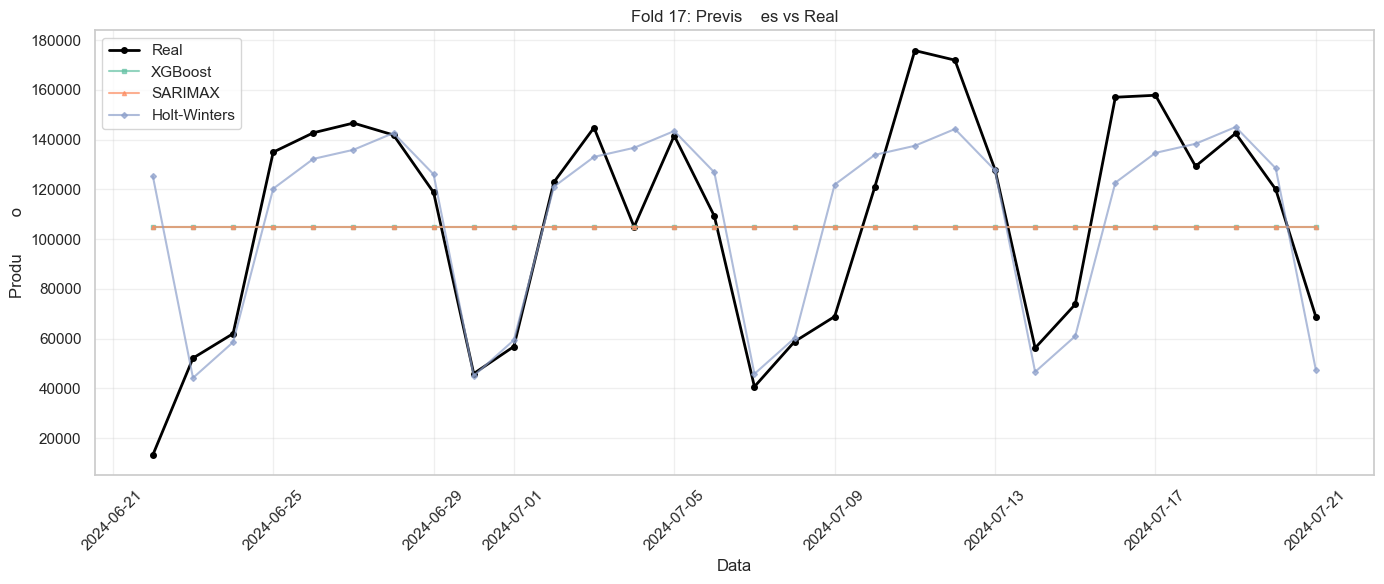


FOLD 18
           Treino: 01/01/2024 at     28/06/2024 (166 dias)
           Teste:  29/06/2024 at     28/07/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:56:04] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(2,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 15672.30 | RMSE: 20918.04 | MAPE: 15.04%


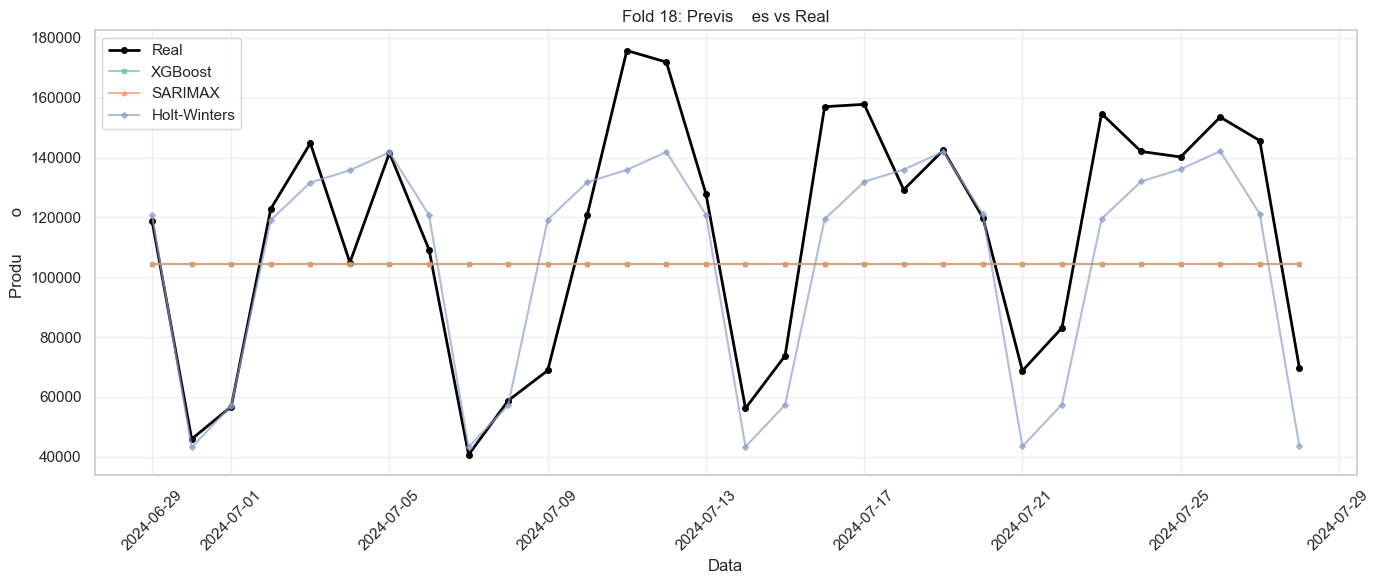


FOLD 19
           Treino: 01/01/2024 at     05/07/2024 (173 dias)
           Teste:  06/07/2024 at     04/08/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:56:21] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(0,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 17665.45 | RMSE: 22086.55 | MAPE: 16.94%


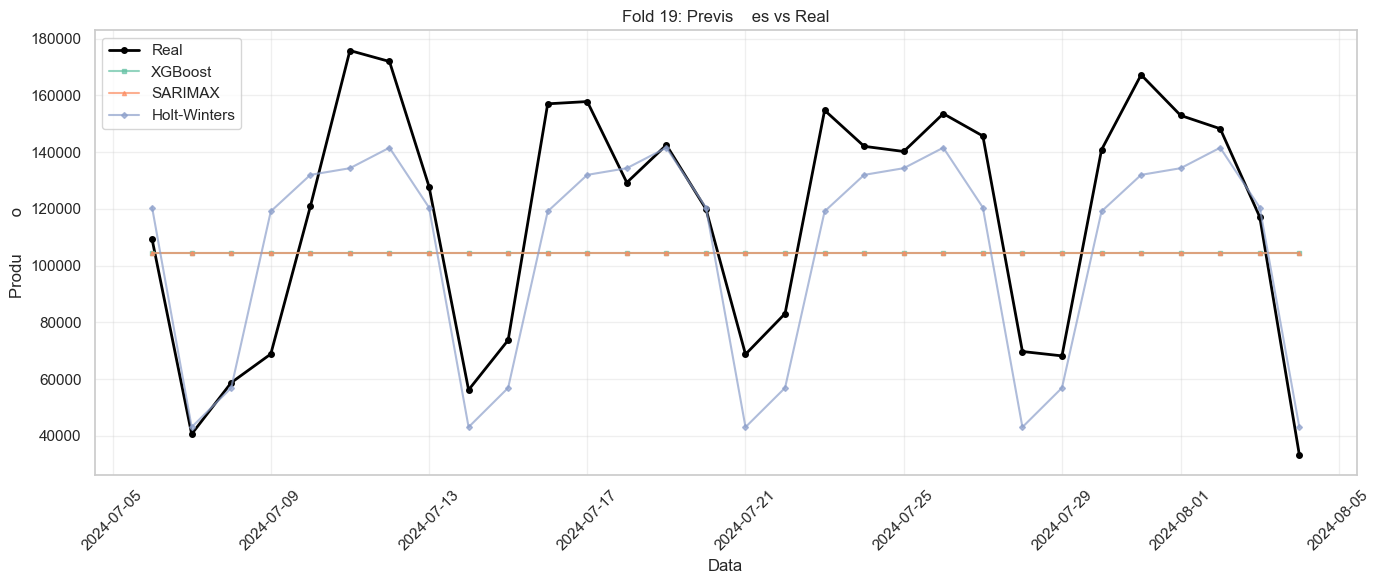


FOLD 20
           Treino: 01/01/2024 at     12/07/2024 (180 dias)
           Teste:  13/07/2024 at     11/08/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:56:35] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(1,1,1,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 18785.33 | RMSE: 22339.72 | MAPE: 17.27%


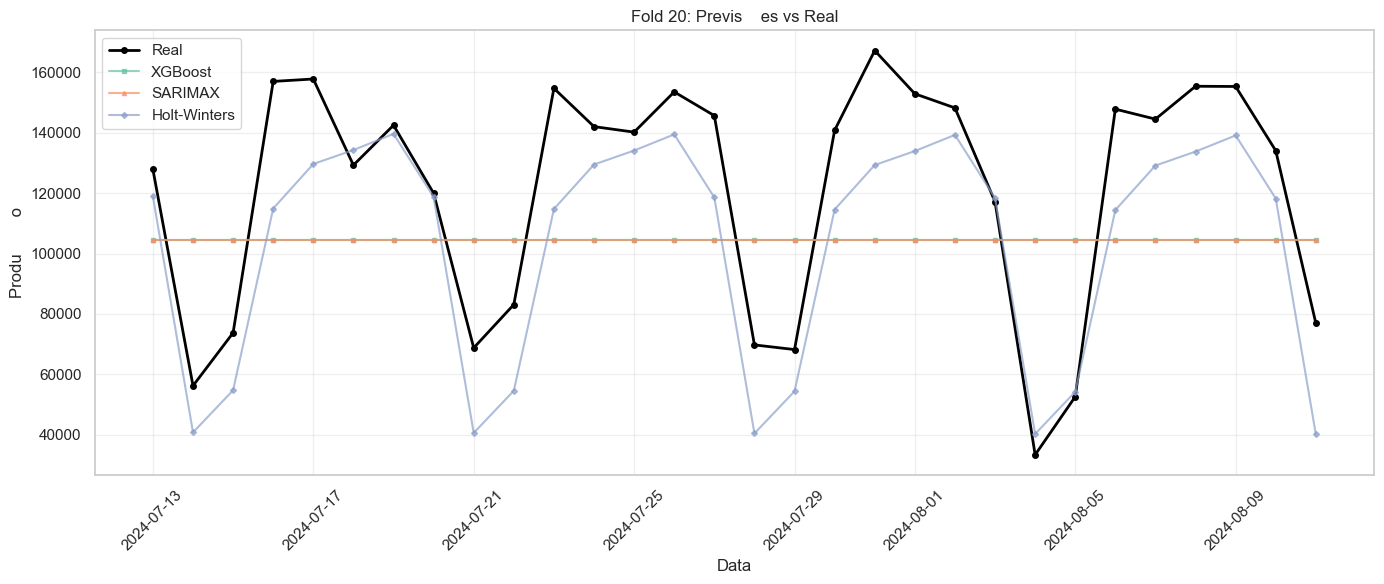


FOLD 21
           Treino: 01/01/2024 at     19/07/2024 (187 dias)
           Teste:  20/07/2024 at     18/08/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:56:47] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,2), seasonal_order=(0,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 22007.17 | RMSE: 37281.72 | MAPE: 64.28%


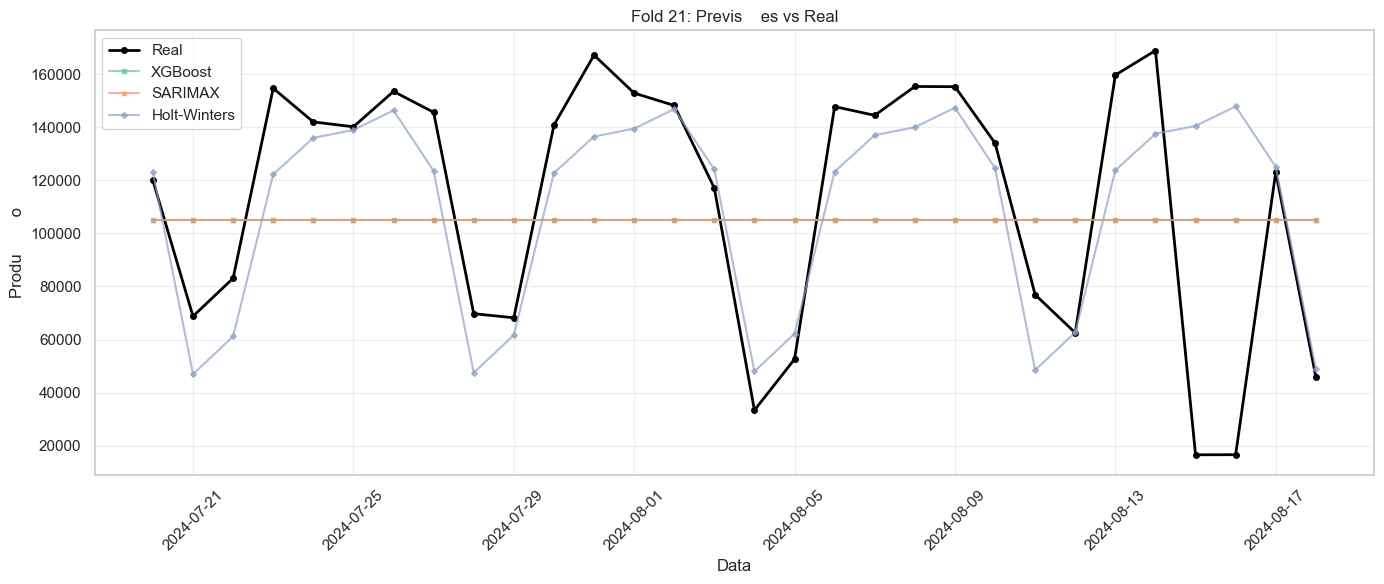


FOLD 22
           Treino: 01/01/2024 at     26/07/2024 (194 dias)
           Teste:  27/07/2024 at     25/08/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:57:03] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(0,1,1,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 20881.69 | RMSE: 37289.13 | MAPE: 64.30%


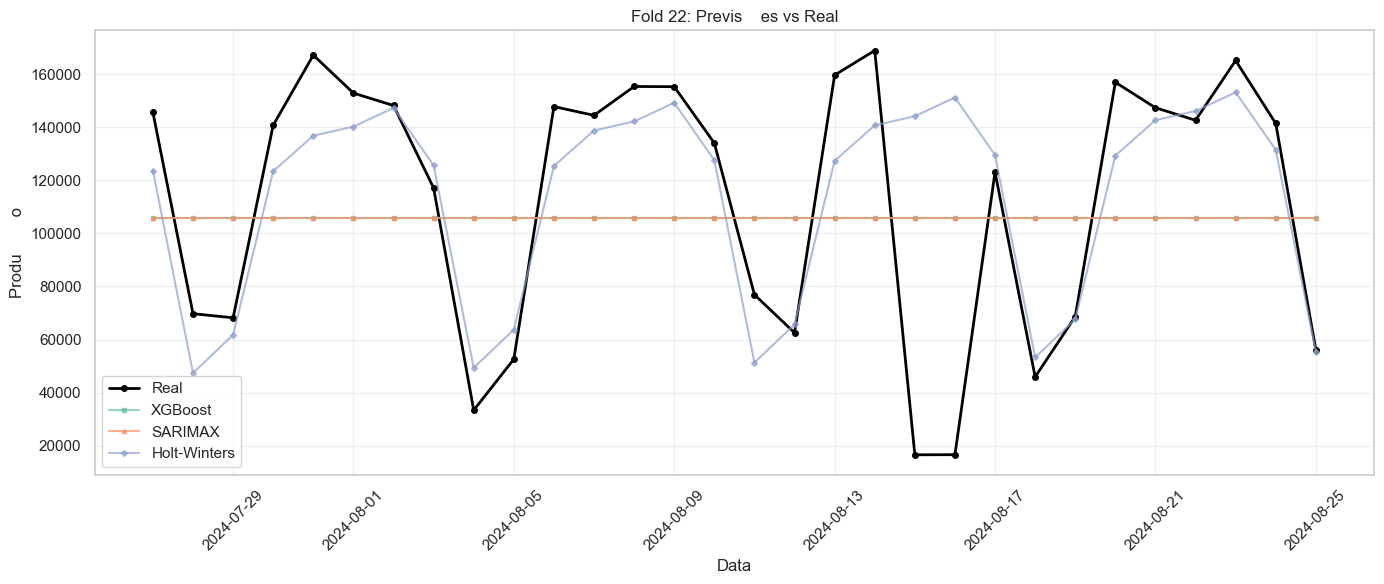


FOLD 23
           Treino: 01/01/2024 at     02/08/2024 (201 dias)
           Teste:  03/08/2024 at     01/09/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:57:15] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,3), seasonal_order=(1,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 21339.18 | RMSE: 39142.99 | MAPE: 104.06%


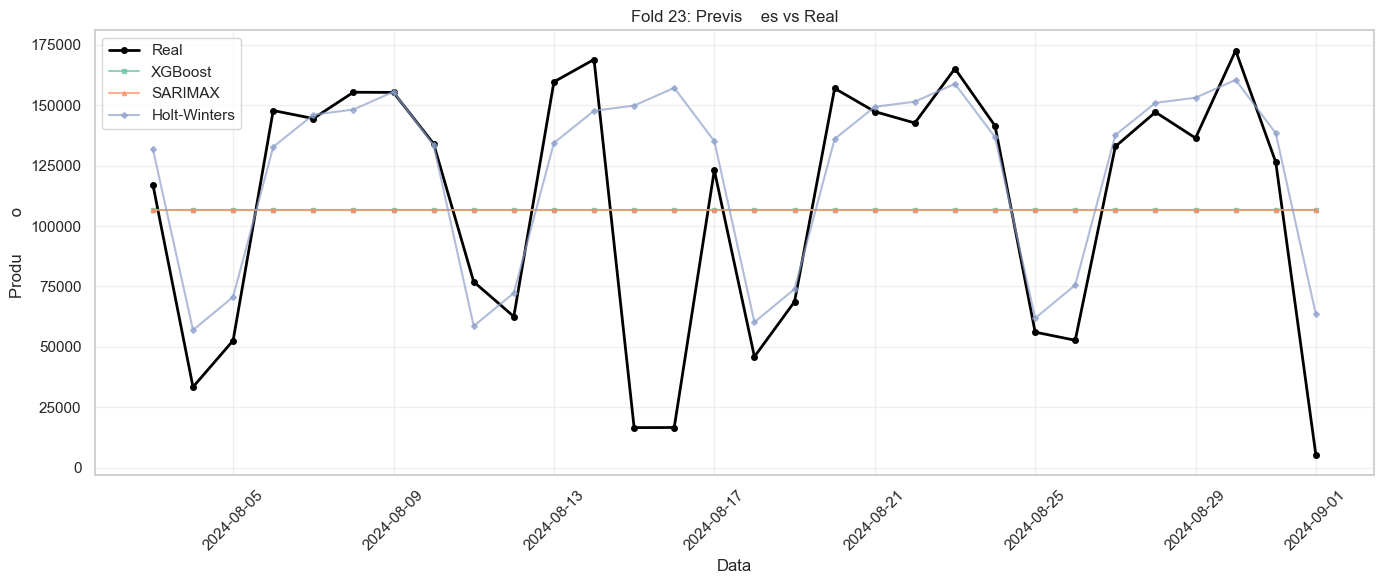


FOLD 24
           Treino: 01/01/2024 at     09/08/2024 (208 dias)
           Teste:  10/08/2024 at     08/09/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:57:35] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(1,1,3), seasonal_order=(2,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 28756.67 | RMSE: 48578.73 | MAPE: 143.17%


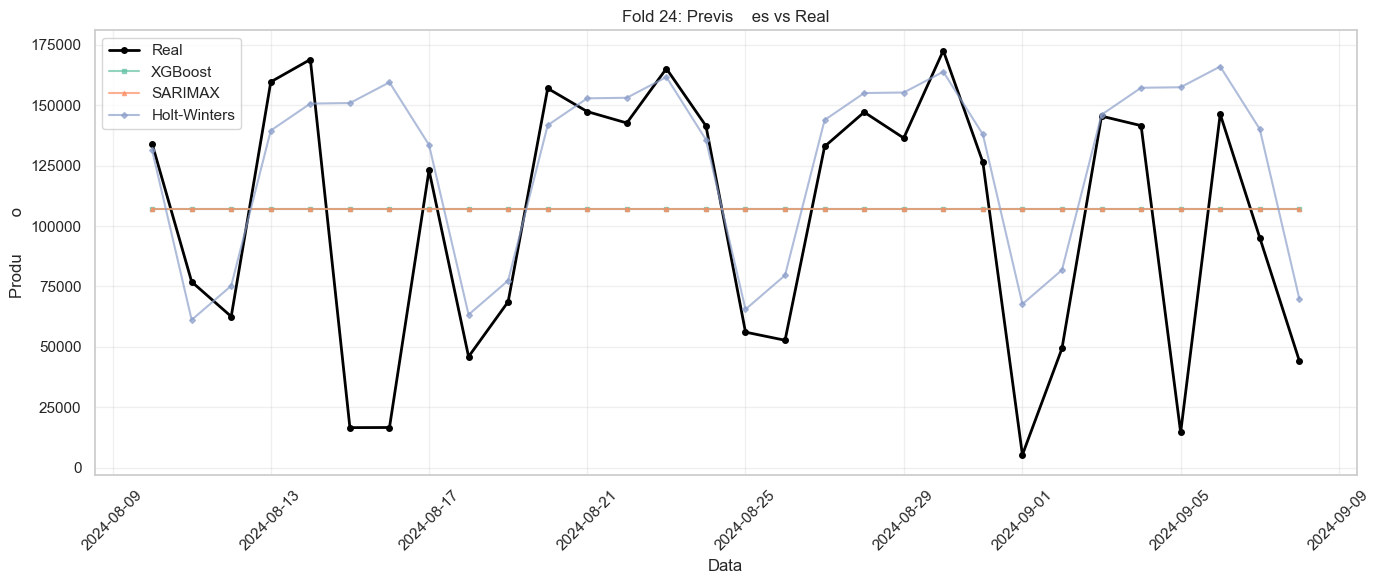


FOLD 25
           Treino: 01/01/2024 at     16/08/2024 (215 dias)
           Teste:  17/08/2024 at     15/09/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:57:50] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(0,1,3), seasonal_order=(2,0,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 15099.75 | RMSE: 27363.35 | MAPE: 72.60%


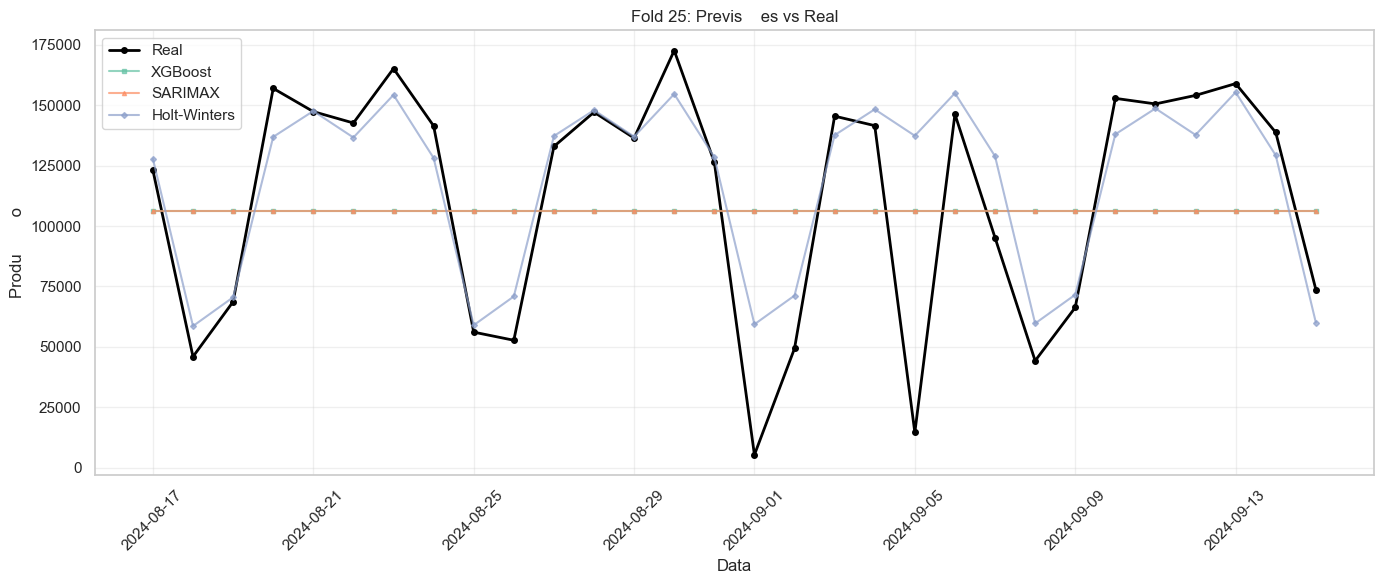


FOLD 26
           Treino: 01/01/2024 at     23/08/2024 (222 dias)
           Teste:  24/08/2024 at     22/09/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:58:09] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(0,0,1), seasonal_order=(0,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 16789.92 | RMSE: 28724.06 | MAPE: 75.36%


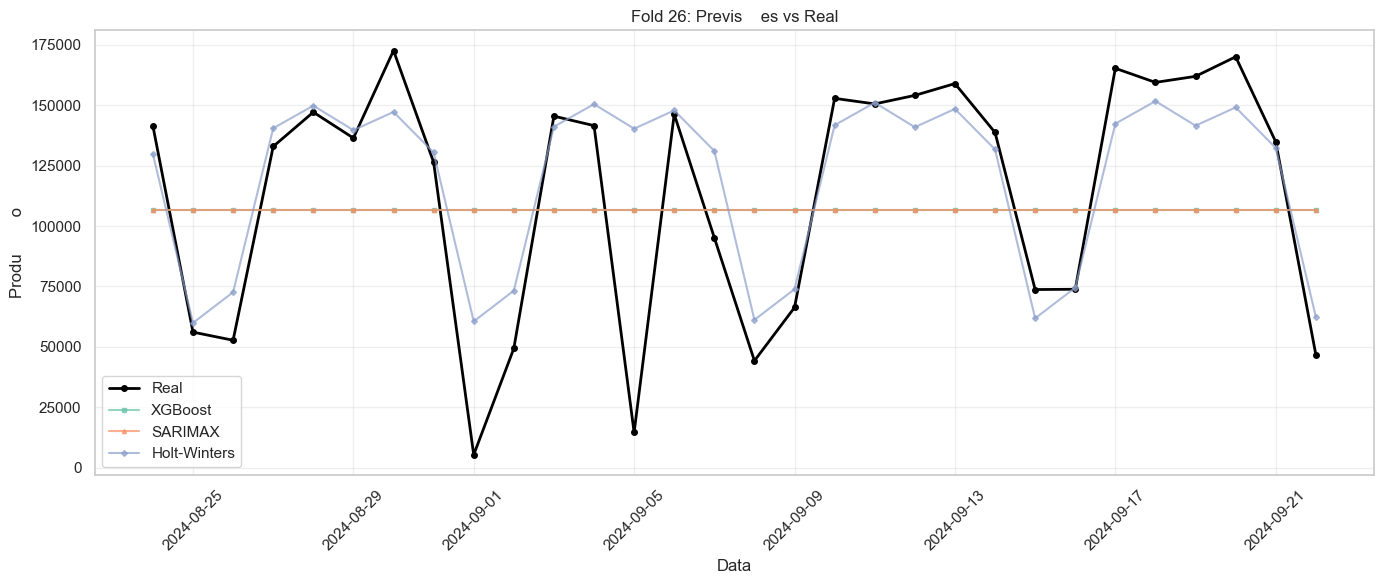


FOLD 27
           Treino: 01/01/2024 at     30/08/2024 (229 dias)
           Teste:  31/08/2024 at     29/09/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:58:17] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,0), seasonal_order=(2,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 17324.00 | RMSE: 28763.15 | MAPE: 75.67%


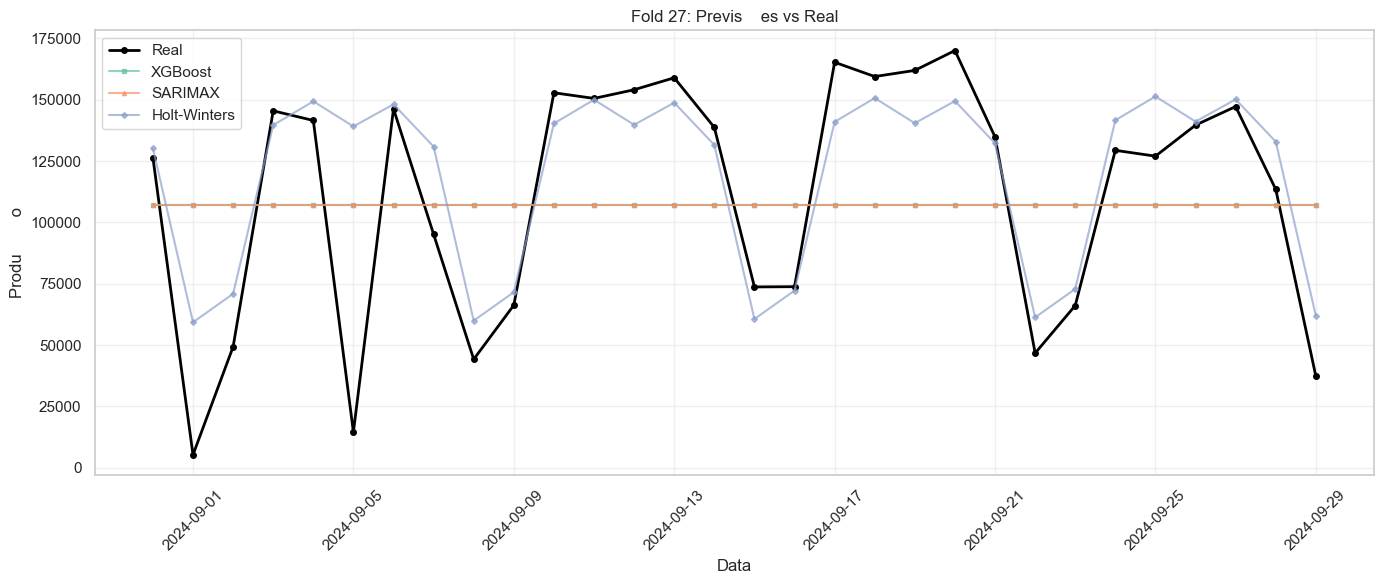


FOLD 28
           Treino: 01/01/2024 at     06/09/2024 (236 dias)
           Teste:  07/09/2024 at     06/10/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:58:23] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(2,0,0), seasonal_order=(2,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 19955.97 | RMSE: 29399.62 | MAPE: 94.68%


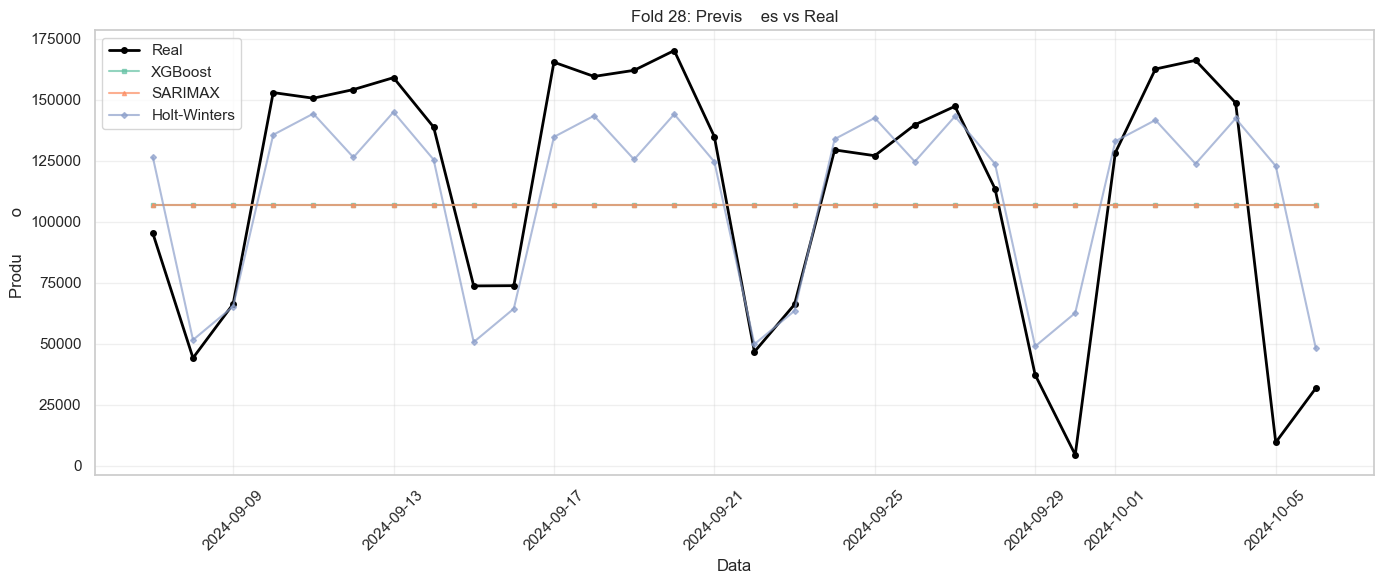


FOLD 29
           Treino: 01/01/2024 at     13/09/2024 (243 dias)
           Teste:  14/09/2024 at     13/10/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:58:30] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...
   Melhor config: order=(3,0,0), seasonal_order=(1,1,2,7)
          Erro no SARIMAX: exog contains inf or nans

          Treinando Holt-Winters...
   MAE: 22165.26 | RMSE: 34762.54 | MAPE: 130.29%


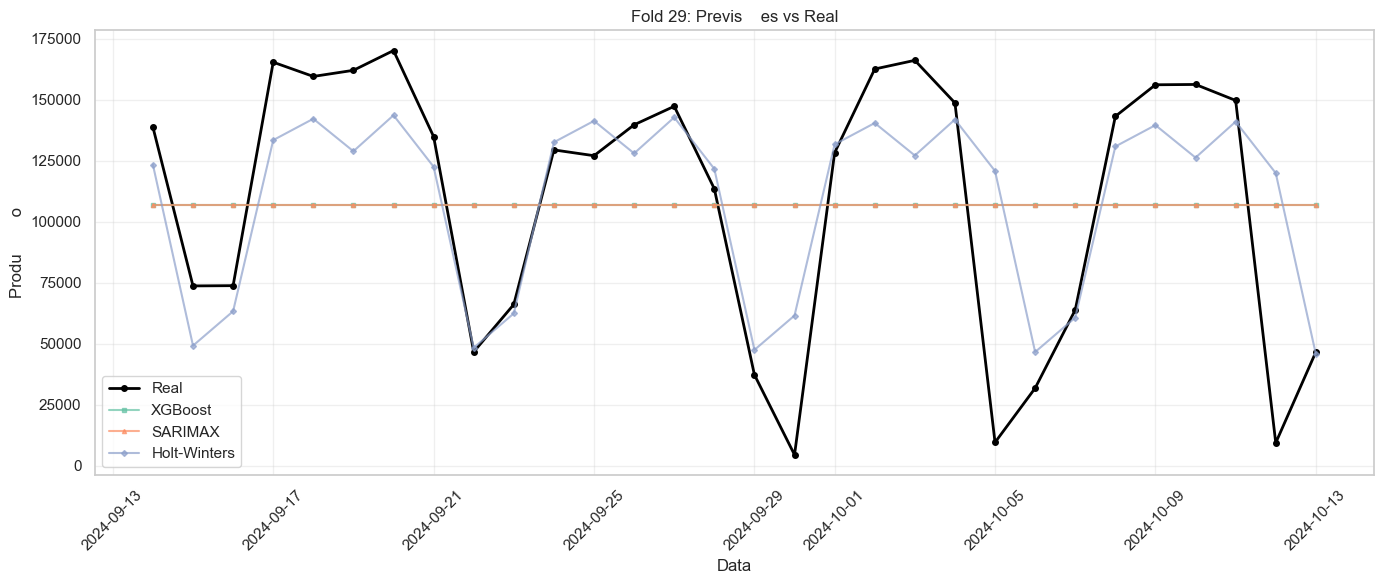


FOLD 30
           Treino: 01/01/2024 at     20/09/2024 (250 dias)
           Teste:  21/09/2024 at     20/10/2024 (30 dias)

          Treinando XGBoost...
          Erro no XGBoost: [16:58:43] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

          Treinando SARIMAX...


In [ ]:
# =============================================================================
# 8.3. LOOP DE VALIDA         O CRUZADA TEMPORAL
# =============================================================================

print("\n" + "="*80)
print("INICIANDO VALIDA         O CRUZADA TEMPORAL")
print("="*80)

# Armazenar resultados
resultados_cv = []
parametros_por_fold = {'XGBoost': [], 'SARIMAX': [], 'HoltWinters': []}
previsoes_por_modelo = {'XGBoost': [], 'SARIMAX': [], 'HoltWinters': []}
valores_reais_total = []

best_hparams_global = {'XGBoost': None, 'SARIMAX': None, 'HoltWinters': None}
datas_previsao_total = []

# Calcular n    mero de folds
tamanho_minimo_treino = 60  # m    nimo 60 dias para treino inicial
data_fim = df_model['data'].max()
fold_num = 0

# Iterar expandindo janela de treino
data_treino_fim = DATA_INICIAL + timedelta(days=tamanho_minimo_treino)

while data_treino_fim + timedelta(days=JANELA_PREVISAO) <= data_fim:
    fold_num += 1
    
    # Definir per    odos
    data_teste_inicio = data_treino_fim + timedelta(days=1)
    data_teste_fim = data_teste_inicio + timedelta(days=JANELA_PREVISAO - 1)
    
    # Criar conjuntos de treino e teste
    mask_train = (df_model['data'] >= DATA_INICIAL) & (df_model['data'] <= data_treino_fim)
    mask_test = (df_model['data'] >= data_teste_inicio) & (df_model['data'] <= data_teste_fim)
    
    train_data = df_model[mask_train].copy()
    test_data = df_model[mask_test].copy()
    
    if len(test_data) == 0:
        break
    
    print(f"\n{'='*80}")
    print(f"FOLD {fold_num}")
    print(f"{'='*80}")
    print(f"           Treino: {DATA_INICIAL.strftime('%d/%m/%Y')} at     {data_treino_fim.strftime('%d/%m/%Y')} ({len(train_data)} dias)")
    print(f"           Teste:  {data_teste_inicio.strftime('%d/%m/%Y')} at     {data_teste_fim.strftime('%d/%m/%Y')} ({len(test_data)} dias)")
    
    # Preparar dados
    X_train = train_data[feature_cols]
    y_train = train_data['producao']
    X_test = test_data[feature_cols]
    y_test = test_data['producao']
    
    # Dividir treino em treino/valida        o para tuning
    split_idx = int(len(train_data) * 0.8)
    X_train_tune = X_train.iloc[:split_idx]
    y_train_tune = y_train.iloc[:split_idx]
    X_val_tune = X_train.iloc[split_idx:]
    y_val_tune = y_train.iloc[split_idx:]
    
    # =========================================================================
    # MODELO 1: XGBOOST
    # =========================================================================
    print(f"\n          Treinando XGBoost...")
    
    try:
        # Tuning iterativo n  o-regressivo
        best_xgb_params = tune_xgboost_iter(X_train_tune, y_train_tune, X_val_tune, y_val_tune,
                                           start_params=best_hparams_global["XGBoost"], n_iter=15)
        best_hparams_global["XGBoost"] = best_xgb_params
        parametros_por_fold["XGBoost"].append({"fold": fold_num, "params": best_xgb_params})
        print(f"   Melhores parametros: {best_xgb_params}")

        # Treinar modelo final com todos os dados de treino
        model_xgb_cv = xgb.XGBRegressor(**best_xgb_params, random_state=42, objective="reg:squarederror")
        model_xgb_cv.fit(X_train, y_train, verbose=False)

        # Previs  o
        y_pred_xgb = model_xgb_cv.predict(X_test)
        y_pred_xgb = np.maximum(y_pred_xgb, 0)  # Evitar valores negativos
        mae_xgb, rmse_xgb, mape_xgb = calcular_metricas(y_test, y_pred_xgb)
        previsoes_por_modelo['XGBoost'].append({
            'fold': fold_num,
            'previsoes': y_pred_xgb,
            'datas': test_data['data'].values,
            'y_true': y_test.values
        })
        print(f"   MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | MAPE: {mape_xgb:.2f}%")

        
    except Exception as e:
        print(f"          Erro no XGBoost: {str(e)}")
        mae_xgb, rmse_xgb, mape_xgb = np.nan, np.nan, np.nan
        y_pred_xgb = np.full(len(y_test), y_train.mean())
    
    # =========================================================================
    # MODELO 2: SARIMAX
    # =========================================================================
    print(f"\n          Treinando SARIMAX...")
    
    try:
        # Tuning iterativo n  o-regressivo
        best_sarimax_config = tune_sarimax_iter(y_train_tune, y_val_tune, seasonal_period=7,
                                               start_cfg=best_hparams_global["SARIMAX"], n_iter=12)
        p, d, q, P, D, Q, s = (best_sarimax_config[k] for k in ["p","d","q","P","D","Q","s"])
        best_hparams_global["SARIMAX"] = best_sarimax_config
        parametros_por_fold["SARIMAX"].append({"fold": fold_num, "params": best_sarimax_config})
        print(f"   Melhor config: order=({p},{d},{q}), seasonal_order=({P},{D},{Q},{s})")

        # Treinar modelo
        model_sarimax_cv = SARIMAX(y_train, exog=train_data[exog_cols].fillna(0), order=(p,d,q), seasonal_order=(P,D,Q,s),
                                   enforce_stationarity=False, enforce_invertibility=False)
        fitted_sarimax = model_sarimax_cv.fit(disp=False, maxiter=100)

        # Previs  o
        y_pred_sarimax = fitted_sarimax.forecast(steps=len(y_test), exog=test_data[exog_cols].fillna(0))
        y_pred_sarimax = np.maximum(y_pred_sarimax, 0)
        mae_sarimax, rmse_sarimax, mape_sarimax = calcular_metricas(y_test, y_pred_sarimax)
        previsoes_por_modelo['SARIMAX'].append({
            'fold': fold_num,
            'previsoes': y_pred_sarimax.values if hasattr(y_pred_sarimax, 'values') else y_pred_sarimax,
            'datas': test_data['data'].values,
            'y_true': y_test.values
        })
        print(f"   MAE: {mae_sarimax:.2f} | RMSE: {rmse_sarimax:.2f} | MAPE: {mape_sarimax:.2f}%")

        
    except Exception as e:
        print(f"          Erro no SARIMAX: {str(e)}")
        mae_sarimax, rmse_sarimax, mape_sarimax = np.nan, np.nan, np.nan
        y_pred_sarimax = np.full(len(y_test), y_train.mean())
    
    # =========================================================================
    # MODELO 3: HOLT-WINTERS
    # =========================================================================
    print(f"\n          Treinando Holt-Winters...")
    
    try:
        # Tuning iterativo n  o-regressivo (suaviza    es)
        best_hw_params = tune_hw_iter(y_train_tune, y_val_tune, seasonal_period=7,
                                      start_params=best_hparams_global["HoltWinters"], n_iter=12)
        best_hparams_global["HoltWinters"] = best_hw_params

        # Treino com par  metros fixos (sem otimiza    o)
        model_hw_cv = ExponentialSmoothing(y_train, seasonal_periods=7, trend="add", seasonal="add",
                                          initialization_method="estimated")
        fitted_hw = model_hw_cv.fit(optimized=False,
                                    smoothing_level=best_hw_params["alpha"],
                                    smoothing_trend=best_hw_params["beta"],
                                    smoothing_seasonal=best_hw_params["gamma"])
        parametros_por_fold["HoltWinters"].append({"fold": fold_num, "params": best_hw_params})

        # Previs  o
        y_pred_hw = fitted_hw.forecast(steps=len(y_test))
        y_pred_hw = np.maximum(y_pred_hw, 0)
        mae_hw, rmse_hw, mape_hw = calcular_metricas(y_test, y_pred_hw)
        previsoes_por_modelo['HoltWinters'].append({
            'fold': fold_num,
            'previsoes': y_pred_hw.values if hasattr(y_pred_hw, 'values') else y_pred_hw,
            'datas': test_data['data'].values,
            'y_true': y_test.values
        })
        print(f"   MAE: {mae_hw:.2f} | RMSE: {rmse_hw:.2f} | MAPE: {mape_hw:.2f}%")

        
    except Exception as e:
        print(f"          Erro no Holt-Winters: {str(e)}")
        mae_hw, rmse_hw, mape_hw = np.nan, np.nan, np.nan
        y_pred_hw = np.full(len(y_test), y_train.mean())
    
    # Armazenar resultados
    for modelo, mae, rmse, mape in [('XGBoost', mae_xgb, rmse_xgb, mape_xgb),
                                     ('SARIMAX', mae_sarimax, rmse_sarimax, mape_sarimax),
                                     ('HoltWinters', mae_hw, rmse_hw, mape_hw)]:
        resultados_cv.append({
            'fold': fold_num,
            'modelo': modelo,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE_%': mape,
            'inicio_teste': data_teste_inicio,
            'fim_teste': data_teste_fim
        })
    
    # Armazenar valores reais e datas
    valores_reais_total.extend(y_test.values)
    datas_previsao_total.extend(test_data['data'].values)
    
    # Visualizar fold
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(test_data['data'], y_test, 'ko-', label='Real', linewidth=2, markersize=4)
    ax.plot(test_data['data'], y_pred_xgb, 's-', label='XGBoost', alpha=0.7, markersize=3)
    ax.plot(test_data['data'], y_pred_sarimax, '^-', label='SARIMAX', alpha=0.7, markersize=3)
    ax.plot(test_data['data'], y_pred_hw, 'D-', label='Holt-Winters', alpha=0.7, markersize=3)
    ax.set_title(f'Fold {fold_num}: Previs    es vs Real')
    ax.set_xlabel('Data')
    ax.set_ylabel('Produ        o')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Expandir janela de treino
    data_treino_fim += timedelta(days=INCREMENTO_DIAS)

print(f"\n        Valida        o cruzada conclu    da! Total de {fold_num} folds processados.")









In [ ]:
# =============================================================================
# EXPORTAR RESULTADOS DETALHADOS PARA EXCEL
# =============================================================================

print("\n" + "="*80)
print("EXPORTANDO RESULTADOS DETALHADOS PARA EXCEL")
print("="*80)

# Verificar se parametros_por_fold existe, sen    o criar vazio
if 'parametros_por_fold' not in globals():
    print("             AVISO: parametros_por_fold n    o encontrado. Criando estrutura vazia...")
    print("   Para incluir par    metros, re-execute a c    lula de valida        o cruzada (c    lula 28)!")
    parametros_por_fold = {'XGBoost': [], 'SARIMAX': [], 'HoltWinters': []}

# Criar lista para armazenar detalhes completos
detalhes_completos_cv = []

# Processar cada fold para extrair detalhes
for fold_i in range(1, fold_num + 1):
    # Obter previs    es de cada modelo para este fold
    xgb_fold = [p for p in previsoes_por_modelo['XGBoost'] if p['fold'] == fold_i]
    sarimax_fold = [p for p in previsoes_por_modelo['SARIMAX'] if p['fold'] == fold_i]
    hw_fold = [p for p in previsoes_por_modelo['HoltWinters'] if p['fold'] == fold_i]
    
    # Obter par    metros de cada modelo para este fold
    xgb_params_fold = [p for p in parametros_por_fold['XGBoost'] if p['fold'] == fold_i]
    sarimax_params_fold = [p for p in parametros_por_fold['SARIMAX'] if p['fold'] == fold_i]
    hw_params_fold = [p for p in parametros_por_fold['HoltWinters'] if p['fold'] == fold_i]
    
    if xgb_fold and sarimax_fold and hw_fold:
        xgb_data = xgb_fold[0]
        sarimax_data = sarimax_fold[0]
        hw_data = hw_fold[0]
        
        # Obter par    metros
        xgb_params = xgb_params_fold[0]['params'] if xgb_params_fold else {}
        sarimax_params = sarimax_params_fold[0]['params'] if sarimax_params_fold else {}
        hw_params = hw_params_fold[0]['params'] if hw_params_fold else {}
        
        # Formatar par    metros como string
        xgb_params_str = ', '.join([f"{k}={v}" for k, v in xgb_params.items()])
        sarimax_params_str = f"order=({sarimax_params.get('p', 0)},{sarimax_params.get('d', 0)},{sarimax_params.get('q', 0)}), seasonal=({sarimax_params.get('P', 0)},{sarimax_params.get('D', 0)},{sarimax_params.get('Q', 0)},{sarimax_params.get('s', 7)})"
        hw_params_str = ', '.join([f"{k}={v}" for k, v in hw_params.items()])
        
        # Obter m    tricas do fold
        fold_results = [r for r in resultados_cv if r['fold'] == fold_i]
        xgb_metrics = [r for r in fold_results if r['modelo'] == 'XGBoost'][0]
        sarimax_metrics = [r for r in fold_results if r['modelo'] == 'SARIMAX'][0]
        hw_metrics = [r for r in fold_results if r['modelo'] == 'HoltWinters'][0]
        
        # Processar cada data de previs    o
        for idx in range(len(xgb_data['datas'])):
            data_prev = pd.Timestamp(xgb_data['datas'][idx])
            
            prev_xgb = xgb_data['previsoes'][idx]
            prev_sarimax = sarimax_data['previsoes'][idx]
            prev_hw = hw_data['previsoes'][idx]
            real = xgb_data['y_true'][idx]
            
            # Calcular diferen    as
            diff_xgb = prev_xgb - real
            diff_sarimax = prev_sarimax - real
            diff_hw = prev_hw - real
            
            detalhes_completos_cv.append({
                'Fold': fold_i,
                'Data_Inicio_Treino': DATA_INICIAL.strftime('%Y-%m-%d'),
                'Data_Final_Treino': xgb_metrics['inicio_teste'].strftime('%Y-%m-%d'),
                'Data_Previsao': data_prev.strftime('%Y-%m-%d'),
                'Previsao_XGBoost': prev_xgb,
                'Previsao_SARIMAX': prev_sarimax,
                'Previsao_HoltWinters': prev_hw,
                'Producao_Real': real,
                'Diferenca_XGBoost': diff_xgb,
                'Diferenca_SARIMAX': diff_sarimax,
                'Diferenca_HoltWinters': diff_hw,
                'Parametros_XGBoost': xgb_params_str,
                'Parametros_SARIMAX': sarimax_params_str,
                'Parametros_HoltWinters': hw_params_str,
                'MAE_XGBoost': xgb_metrics['MAE'],
                'RMSE_XGBoost': xgb_metrics['RMSE'],
                'MAPE_XGBoost': xgb_metrics['MAPE_%'],
                'MAE_SARIMAX': sarimax_metrics['MAE'],
                'RMSE_SARIMAX': sarimax_metrics['RMSE'],
                'MAPE_SARIMAX': sarimax_metrics['MAPE_%'],
                'MAE_HoltWinters': hw_metrics['MAE'],
                'RMSE_HoltWinters': hw_metrics['RMSE'],
                'MAPE_HoltWinters': hw_metrics['MAPE_%']
            })

# Criar DataFrame com todos os detalhes
df_detalhes_completos = pd.DataFrame(detalhes_completos_cv)

# Criar arquivo Excel com m    ltiplas abas
arquivo_excel = 'validacao_cruzada_detalhada.xlsx'

with pd.ExcelWriter(arquivo_excel, engine='openpyxl') as writer:
    # Aba 1: Detalhes completos (todas as previs    es linha por linha)
    df_detalhes_completos.to_excel(writer, sheet_name='Detalhes_Completos', index=False)
    
    # Aba 2: Resumo por fold e modelo
    df_resultados_cv = pd.DataFrame(resultados_cv)
    resumo_fold = df_resultados_cv.groupby(['fold', 'modelo']).agg({
        'MAE': 'mean',
        'RMSE': 'mean',
        'MAPE_%': 'mean'
    }).reset_index()
    resumo_fold.to_excel(writer, sheet_name='Resumo_Metricas', index=False)
    
    # Aba 3: Estat    sticas gerais por modelo
    estatisticas_modelo = df_resultados_cv.groupby('modelo').agg({
        'MAE': ['mean', 'std', 'min', 'max'],
        'RMSE': ['mean', 'std', 'min', 'max'],
        'MAPE_%': ['mean', 'std', 'min', 'max']
    })
    estatisticas_modelo.to_excel(writer, sheet_name='Estatisticas_Gerais')
    
    # Aba 4: Informa        es dos folds
    info_folds = df_resultados_cv[['fold', 'inicio_teste', 'fim_teste']].drop_duplicates()
    info_folds.to_excel(writer, sheet_name='Info_Folds', index=False)

print(f"\n        Arquivo salvo: {arquivo_excel}")
print(f"             Total de registros exportados: {len(df_detalhes_completos)}")
print(f"              Abas criadas:")
print(f"      1. Detalhes_Completos - Todas as previs    es com diferen    as")
print(f"      2. Resumo_Metricas - M    tricas por fold e modelo")
print(f"      3. Estatisticas_Gerais - Estat    sticas agregadas")
print(f"      4. Info_Folds - Informa        es de cada fold")



EXPORTANDO RESULTADOS DETALHADOS PARA EXCEL

        Arquivo salvo: validacao_cruzada_detalhada.xlsx
             Total de registros exportados: 30
              Abas criadas:
      1. Detalhes_Completos - Todas as previs    es com diferen    as
      2. Resumo_Metricas - M    tricas por fold e modelo
      3. Estatisticas_Gerais - Estat    sticas agregadas
      4. Info_Folds - Informa        es de cada fold


## 9. Modelo Ensemble - Sele        o do Melhor por Janela

Constru        o de um modelo ensemble que seleciona o melhor modelo para cada janela de previs    o baseado em m    tricas de performance.



CONSTRUINDO MODELO ENSEMBLE
Fold 1: Modelo selecionado = XGBoost (MAE = 16110.94)


Fold 2: Modelo selecionado = XGBoost (MAE = 16326.89)
Fold 3: Modelo selecionado = XGBoost (MAE = 13292.59)
Fold 4: Modelo selecionado = XGBoost (MAE = 10936.44)
Fold 5: Modelo selecionado = XGBoost (MAE = 7608.44)
Fold 6: Modelo selecionado = HoltWinters (MAE = 38465.87)
Fold 7: Modelo selecionado = HoltWinters (MAE = 27224.04)
Fold 8: Modelo selecionado = HoltWinters (MAE = 30064.04)
Fold 9: Modelo selecionado = HoltWinters (MAE = 31776.78)
Fold 10: Modelo selecionado = HoltWinters (MAE = 36783.45)
Fold 11: Modelo selecionado = HoltWinters (MAE = 50166.05)
Fold 12: Modelo selecionado = HoltWinters (MAE = 41539.35)
Fold 13: Modelo selecionado = HoltWinters (MAE = 42299.73)
Fold 14: Modelo selecionado = HoltWinters (MAE = 26581.48)
Fold 15: Modelo selecionado = HoltWinters (MAE = 35347.18)
Fold 16: Modelo selecionado = HoltWinters (MAE = 39900.12)
Fold 17: Modelo selecionado = HoltWinters (MAE = 31908.61)
Fold 18: Modelo selecionado = HoltWinters (MAE = 35239.23)
Fold 19: Modelo seleci

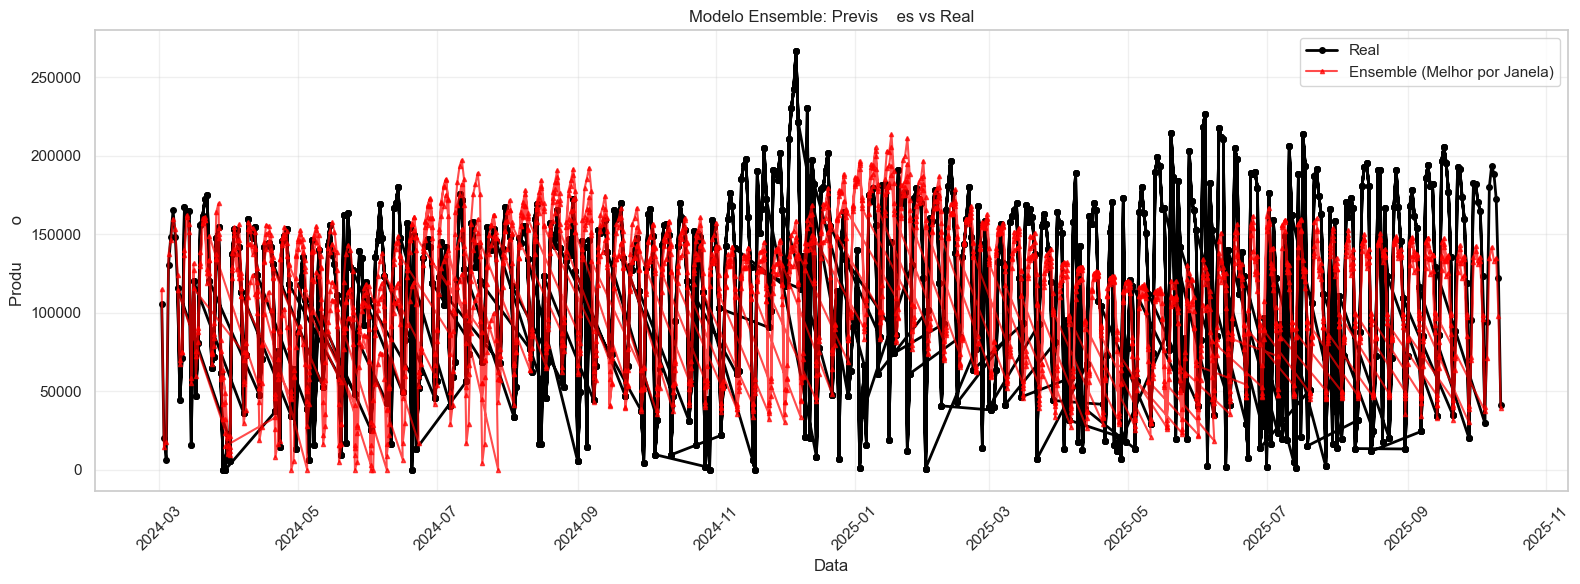


          Distribui        o de modelos selecionados:
           XGBoost: 5 folds (6.2%)
           HoltWinters: 76 folds (93.8%)


In [ ]:
# =============================================================================
# 9. MODELO ENSEMBLE - SELE         O DO MELHOR POR JANELA
# =============================================================================

print("\n" + "="*80)
print("CONSTRUINDO MODELO ENSEMBLE")
print("="*80)

# Estrat    gia: selecionar melhor modelo por janela baseado em MAE
previsoes_ensemble = []
modelos_selecionados = []

for fold_i in range(1, fold_num + 1):
    # Obter m    tricas do fold
    fold_results = df_resultados_cv[df_resultados_cv['fold'] == fold_i]
    
    # Identificar modelo com menor MAE
    melhor_modelo = fold_results.loc[fold_results['MAE'].idxmin(), 'modelo']
    modelos_selecionados.append(melhor_modelo)
    
    # Obter previs    es do melhor modelo
    candidatos = [p for p in previsoes_por_modelo.get(melhor_modelo, []) if p.get('fold') == fold_i]
    if not candidatos:
        for alt in ['XGBoost','SARIMAX','HoltWinters']:
            candidatos = [p for p in previsoes_por_modelo.get(alt, []) if p.get('fold') == fold_i]
            if candidatos:
                melhor_modelo = alt
                break
    if not candidatos:
        print(f'[AVISO] Sem previsoes registradas no fold {fold_i}; pulando no ensemble.')
        continue
    previsoes_fold = candidatos[0]
    previsoes_ensemble.extend(previsoes_fold['previsoes'])
    
    mae_fold = fold_results.loc[fold_results['modelo'] == melhor_modelo, 'MAE'].values[0]
    print(f"Fold {fold_i}: Modelo selecionado = {melhor_modelo} (MAE = {mae_fold:.2f})")

# Calcular m    tricas do ensemble
mae_ensemble = mean_absolute_error(valores_reais_total, previsoes_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(valores_reais_total, previsoes_ensemble))
mape_ensemble = np.mean(np.abs((np.array(valores_reais_total) - np.array(previsoes_ensemble)) / 
                                 np.where(np.array(valores_reais_total) != 0, np.array(valores_reais_total), 1))) * 100

print(f"\n          Performance do Ensemble:")
print(f"           MAE:  {mae_ensemble:.2f}")
print(f"           RMSE: {rmse_ensemble:.2f}")
print(f"           MAPE: {mape_ensemble:.2f}%")

# Visualizar s    rie ensemble
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(datas_previsao_total, valores_reais_total, 'ko-', label='Real', linewidth=2, markersize=4)
ax.plot(datas_previsao_total, previsoes_ensemble, 'r^-', label='Ensemble (Melhor por Janela)', alpha=0.7, markersize=3)
ax.set_title('Modelo Ensemble: Previs    es vs Real')
ax.set_xlabel('Data')
ax.set_ylabel('Produ        o')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribui        o de modelos selecionados
from collections import Counter
contagem_modelos = Counter(modelos_selecionados)

print(f"\n          Distribui        o de modelos selecionados:")
for modelo, count in contagem_modelos.items():
    percentual = (count / len(modelos_selecionados)) * 100
    print(f"           {modelo}: {count} folds ({percentual:.1f}%)")




## 10. Previs    o Final para os Pr    ximos 30 Dias

Treinamento dos modelos finais com todos os dados hist    ricos e gera        o de previs    es para os pr    ximos 30 dias.


In [ ]:
# =============================================================================
# 10.1. PREPARA         O DOS DADOS FUTUROS
# =============================================================================

print("\n" + "="*80)
print("PREVIS    O PARA OS PR     XIMOS 30 DIAS")
print("="*80)

# Preparar dados completos para treino final
X_final = df_model[feature_cols]
y_final = df_model['producao']

# Data de in    cio da previs    o
data_ultima = df_model['data'].max()
data_inicio_previsao = data_ultima + timedelta(days=1)
data_fim_previsao = data_inicio_previsao + timedelta(days=29)

print(f"\n           Per    odo de previs    o: {data_inicio_previsao.strftime('%d/%m/%Y')} a {data_fim_previsao.strftime('%d/%m/%Y')}")

# Gerar datas futuras
datas_futuras = pd.date_range(start=data_inicio_previsao, end=data_fim_previsao, freq='D')

print("\n          Gerando features para datas futuras...")

# Criar DataFrame com datas futuras
df_futuro = pd.DataFrame({'data': datas_futuras})

# Adicionar features temporais b    sicas
df_futuro['mes'] = df_futuro['data'].dt.month
df_futuro['dia_semana'] = df_futuro['data'].dt.dayofweek
df_futuro['ano'] = df_futuro['data'].dt.year
df_futuro['dia_mes'] = df_futuro['data'].dt.day

# Adicionar features de sazonalidade
df_futuro['eh_domingo'] = (df_futuro['dia_semana'] == 6).astype(int)
df_futuro['eh_sabado'] = (df_futuro['dia_semana'] == 5).astype(int)
df_futuro['eh_dia_util'] = df_futuro['dia_semana'].apply(lambda x: 1 if x < 5 else 0)

# Dummies de dias da semana
dias_semana_lista = ['segunda', 'terca', 'quarta', 'quinta', 'sexta', 'sabado', 'domingo']
for i, dia in enumerate(dias_semana_lista):
    df_futuro[f'dia_{dia}'] = (df_futuro['dia_semana'] == i).astype(int)

# Intera        es
df_futuro['domingo_mes'] = df_futuro['eh_domingo'] * df_futuro['mes']
df_futuro['domingo_feriado'] = 0  # Assumir sem feriado (ajustar se necess    rio)

# Para lags e m    dias m    veis, usar     ltimos valores conhecidos
ultimos_valores = y_final.tail(30).values

# Lags (usar     ltimos valores)
df_futuro['producao_lag_1'] = ultimos_valores[-1]
df_futuro['producao_lag_7'] = ultimos_valores[-7] if len(ultimos_valores) >= 7 else ultimos_valores.mean()
df_futuro['producao_lag_14'] = ultimos_valores[-14] if len(ultimos_valores) >= 14 else ultimos_valores.mean()

# M    dias m    veis (usar     ltimos valores)
df_futuro['producao_ma_7'] = ultimos_valores[-7:].mean() if len(ultimos_valores) >= 7 else ultimos_valores.mean()
df_futuro['producao_ma_14'] = ultimos_valores[-14:].mean() if len(ultimos_valores) >= 14 else ultimos_valores.mean()
df_futuro['producao_ma_30'] = ultimos_valores.mean()

# Features avancadas no futuro
_df_fut = criar_features_avancadas(df_futuro)
if _df_fut is not None: df_futuro = _df_fut

# Adicionar colunas faltantes (eventos, feriados, etc.)
for col in feature_cols:
    if col not in df_futuro.columns:
        df_futuro[col] = 0  # Valor padr    o

# Garantir mesma ordem de colunas
df_futuro = df_futuro[feature_cols]

print(f"        Features geradas: {df_futuro.shape}")




PREVIS    O PARA OS PR     XIMOS 30 DIAS

           Per    odo de previs    o: 15/10/2025 a 13/11/2025

          Gerando features para datas futuras...
        Features geradas: (30, 103)


In [ ]:
# =============================================================================
# 10.2. TREINAMENTO DOS MODELOS FINAIS E PREVIS    O
# =============================================================================

print("\n          Treinando modelos finais...")

# XGBoost Final
best_xgb_params_final = tune_xgboost_iter(
    X_final.iloc[:int(len(X_final)*0.8)],
    y_final.iloc[:int(len(y_final)*0.8)],
    X_final.iloc[int(len(X_final)*0.8):],
    y_final.iloc[int(len(y_final)*0.8):]
)

model_xgb_final = xgb.XGBRegressor(**best_xgb_params_final, random_state=42, objective='reg:squarederror')
model_xgb_final.fit(X_final, y_final, verbose=False)
previsao_xgb_final = np.maximum(model_xgb_final.predict(df_futuro), 0)

print("        XGBoost treinado")

# SARIMAX Final
best_sarimax_config_final = tune_sarimax_iter(y_final.iloc[:int(len(y_final)*0.8)], y_final.iloc[int(len(y_final)*0.8):], seasonal_period=7)
cfg = best_sarimax_config_final
p, d, q, P, D, Q, s = cfg['p'], cfg['d'], cfg['q'], cfg['P'], cfg['D'], cfg['Q'], cfg['s']

model_sarimax_final = SARIMAX(
    y_final,
    exog=X_final[exog_cols].fillna(0),
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_sarimax_final = model_sarimax_final.fit(disp=False, maxiter=100)
previsao_sarimax_final = np.maximum(fitted_sarimax_final.forecast(steps=30, exog=df_futuro[exog_cols].fillna(0)), 0)

print("        SARIMAX treinado")

# Holt-Winters Final
# Tuning iterativo para HW em split 80/20
_best_hw = tune_hw_iter(y_final.iloc[:int(len(y_final)*0.8)], y_final.iloc[int(len(y_final)*0.8):], seasonal_period=7)
model_hw_final = ExponentialSmoothing(
    y_final,
    seasonal_periods=7,
    trend='add',
    seasonal='add',
    initialization_method='estimated'
)
fitted_hw_final = model_hw_final.fit(optimized=False, smoothing_level=_best_hw['alpha'], smoothing_trend=_best_hw['beta'], smoothing_seasonal=_best_hw['gamma'])
previsao_hw_final = np.maximum(fitted_hw_final.forecast(steps=30), 0)

print("        Holt-Winters treinado")

# Ensemble: m    dia ponderada baseada em performance hist    rica
pesos = {}
for modelo in ['XGBoost', 'SARIMAX', 'HoltWinters']:
    mae_media = df_resultados_cv[df_resultados_cv['modelo'] == modelo]['MAE'].mean()
    pesos[modelo] = 1 / mae_media if not np.isnan(mae_media) else 0

# Normalizar pesos
soma_pesos = sum(pesos.values())
pesos = {k: v/soma_pesos for k, v in pesos.items()}

print(f"\n          Pesos do ensemble:")
for modelo, peso in pesos.items():
    print(f"           {modelo}: {peso:.3f}")

# Previs    o ensemble
previsao_ensemble_final = (
    pesos['XGBoost'] * previsao_xgb_final +
    pesos['SARIMAX'] * previsao_sarimax_final +
    pesos['HoltWinters'] * previsao_hw_final
)

# Ajuste por eventos (opcional)
if AJUSTE_EVENTOS:
    _trat = TratadorEventosEspeciais(); _trat.calcular_impacto_eventos(df)
    previsao_ensemble_ajustada = _trat.ajustar_previsao_eventos(df_futuro, previsao_ensemble_final)
else:
    previsao_ensemble_ajustada = previsao_ensemble_final

# Criar DataFrame de previs    es
df_previsao_final = pd.DataFrame({
    'data': datas_futuras,
    'XGBoost': previsao_xgb_final,
    'SARIMAX': previsao_sarimax_final,
    'HoltWinters': previsao_hw_final,
    'Ensemble': previsao_ensemble_final,
    'Ensemble_Ajustado': previsao_ensemble_ajustada
})

print("\n          Previs    es para os pr    ximos 30 dias:")
display(df_previsao_final)

# Visualizar previs    es
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_model['data'].tail(60), df_model['producao'].tail(60), 'ko-', label='Hist    rico', linewidth=2, markersize=4)
ax.plot(datas_futuras, previsao_xgb_final, 's-', label='XGBoost', alpha=0.7, markersize=3)
ax.plot(datas_futuras, previsao_sarimax_final, '^-', label='SARIMAX', alpha=0.7, markersize=3)
ax.plot(datas_futuras, previsao_hw_final, 'D-', label='Holt-Winters', alpha=0.7, markersize=3)
ax.plot(datas_futuras, previsao_ensemble_final, 'r*-', label='Ensemble', linewidth=2, markersize=6)
ax.axvline(x=data_ultima, color='gray', linestyle='--', linewidth=1.5, label='In    cio Previs    o')
ax.set_title('Previs    o para os Pr    ximos 30 Dias')
ax.set_xlabel('Data')
ax.set_ylabel('Produ        o')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Validacao temporal expandida (30/60/90)
try:
    _model_val = xgb.XGBRegressor(**best_xgb_params_final, random_state=42, objective='reg:squarederror')
    validacao_exp = validacao_temporal_robusta(df_model[['data']+feature_cols+['producao']].copy(), _model_val, feature_cols)
except Exception:
    validacao_exp = pd.DataFrame()

# Salvar previs    es em Excel
output_file = 'previsao_30_dias.xlsx'
# Garante 'resumo_cv' dispon vel
if 'resumo_cv' not in globals():
    df_resultados_cv = pd.DataFrame(resultados_cv)
    resumo_cv = df_resultados_cv.groupby('modelo').agg({'MAE':'mean','RMSE':'mean','MAPE_%':'mean'}).reset_index()
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_previsao_final.to_excel(writer, sheet_name='Previs    es', index=False)
    df_resultados_cv.to_excel(writer, sheet_name='Backtest', index=False)
    resumo_cv.to_excel(writer, sheet_name='Resumo')
    if 'validacao_exp' in globals() and not validacao_exp.empty:
        validacao_exp.to_excel(writer, sheet_name='Validacao_Expandida', index=False)

print(f"\n          Previs    es salvas em: {output_file}")

print("\n" + "="*80)
print("        PIPELINE DE MODELAGEM CONCLU    DO COM SUCESSO!")
print("="*80)









          Treinando modelos finais...


XGBoostError: [16:51:00] C:\actions-runner\_work\xgboost\xgboost\src\data\gradient_index.h:100: Check failed: valid: Input data contains `inf` or a value too large, while `missing` is not set to `inf`

In [ ]:
# Diagn    stico: verificar conteudo de parametros_por_fold e previsoes_por_modelo
print('parametros_por_fold existe?', 'parametros_por_fold' in globals())
if 'parametros_por_fold' in globals():
    for modelo in ['XGBoost','SARIMAX','HoltWinters']:
        lista = parametros_por_fold.get(modelo, [])
        print(f"Modelo {modelo}: {len(lista)} registros")
        if lista:
            print('  Exemplo 1:', lista[0])
            print('  Exemplo ultimo:', lista[-1])
    # Checagem por fold
    for f in range(1, fold_num+1):
        x = [p for p in parametros_por_fold.get('XGBoost', []) if p.get('fold')==f]
        s = [p for p in parametros_por_fold.get('SARIMAX', []) if p.get('fold')==f]
        h = [p for p in parametros_por_fold.get('HoltWinters', []) if p.get('fold')==f]
        print(f"Fold {f}: XGB {len(x)} | SARIMAX {len(s)} | HW {len(h)}")
else:
    print('parametros_por_fold NAO encontrado')

# Tamb    m validar previsoes_por_modelo
for modelo in ['XGBoost','SARIMAX','HoltWinters']:
    l = previsoes_por_modelo.get(modelo, [])
    print(f"previsoes_por_modelo[{modelo}] = {len(l)} folds")



parametros_por_fold existe? True
Modelo XGBoost: 81 registros
  Exemplo 1: {'fold': 1, 'params': {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.9}}
  Exemplo ultimo: {'fold': 81, 'params': {'n_estimators': 457, 'learning_rate': 0.1180933639642891, 'max_depth': 6, 'subsample': 0.8468373568903748, 'colsample_bytree': 0.6448070011935488}}
Modelo SARIMAX: 81 registros
  Exemplo 1: {'fold': 1, 'params': {'p': 0, 'd': 0, 'q': 1, 'P': 1, 'D': 0, 'Q': 1, 's': 7}}
  Exemplo ultimo: {'fold': 81, 'params': {'p': 0, 'd': 0, 'q': 1, 'P': 0, 'D': 1, 'Q': 0, 's': 7}}
Modelo HoltWinters: 81 registros
  Exemplo 1: {'fold': 1, 'params': {'alpha': 0.17552539787098248, 'beta': 0.08711812297955512, 'gamma': 0.3305833396003239}}
  Exemplo ultimo: {'fold': 81, 'params': {'alpha': 0.001554062053505231, 'beta': 0.2791229332986522, 'gamma': 0.018729571992532255}}
Fold 1: XGB 1 | SARIMAX 1 | HW 1
Fold 2: XGB 1 | SARIMAX 1 | HW 1
Fold 3: XGB 1 | SARIMAX 1 | HW